## How was data collected (text from 1st milestone):

# Dataset availability, attributes and goal

[https://www.kaggle.com/datasets/mmakarovlab/serbia-car-sales-prices/data
](https://www.kaggle.com/datasets/mmakarovlab/serbia-car-sales-prices/data
)

The dataset contains data from a Serbian used car website; the data is real, collected by the publishing user in October 2024. The CSV file contains the following columns (18 columns, 8413 rows of data + header): 

- **views**: how many people viewed the advertisement
- **favorite**: how many people added the advertisement to their favorites
- **post_info**: when the advertisement was published/updated
- **price**: the price of the car in Euro
- **car_name**: the manufacturer and model name of the car
- **year**: the year the car was manufactured
- **A/C**: is there air conditioning in the car?
- **emission_class**: environmental classification (EURO standard)
- **seats_amount**: number of seats
- **horsepower**: horsepower (also in kW)
- **color**: the color of the car (bodywork)
- **car_mileage, km**: the car's mileage in km
- **engine_capacity, cc**: the engine displacement in cc
- **type_of_drive**: type of drive
- **doors**: number of doors
- **fuel**: type of fuel used
- **car_type**: body style
- **gearbox**: type of gearbox, number of gears

The data still needs cleaning (e.g., missing values), type casting (e.g., floating point number to integer), and many columns need simplification (e.g., keeping only horsepower, discarding kW).

**Goal:** Cleaning and then analyzing the data. Finding correlations between the price and the car's attributes. Using various machine learning methods to determine what price a car could worth based on it's features.

## Data Cleaning

#### Importing every package that we need

In [104]:
#install.packages("tidyverse")
#install.packages("dlookr")
#install.packages("skimr")
#install.packages("embed")
#install.packages("corrplot")
#install.packages("xgboost")
#install.packages("kernlab") 
library(tidyverse)
library(recipes)
library(dlookr)
library(skimr)
library(corrplot)
library(tidymodels)
library(embed)
library(vip)
library(doParallel)
library(finetune)
library(patchwork)
library(knitr)

set.seed(123)

In [2]:
cars_raw = read_csv("serbia_car_sales_price_2024.csv")

Rows: 8413 Columns: 18
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (11): post_info, car_name, A/C, emission_class, horsepower, color, type_...
dbl  (7): views, favorite, price, year, seats_amount, car_mileage, km, engin...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
head(cars_raw)

views,favorite,post_info,price,car_name,year,A/C,emission_class,seats_amount,horsepower,color,"car_mileage, km","engine_capacity, cc",type_of_drive,doors,fuel,car_type,gearbox
<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
58,0,posted a week ago,1100,Alfa Romeo 11.9,2002,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
55,0,posted 2 days ago,1100,Alfa Romeo 145,2000,manual A/C,Euro 3,5,106 HP (78 kW),gray,158546,1400,front,2/3 doors,petrol + gas,hatchback,"manual, 5 speeds"
136,4,posted 2 weeks ago,950,Alfa Romeo 145,1999,manual A/C,Euro 3,5,105 HP (77 kW),green,337000,1910,front,2/3 doors,diesel,hatchback,"manual, 5 speeds"
209,1,posted 4 weeks ago,500,Alfa Romeo 146,2000,manual A/C,Euro 3,5,120 HP (88 kW),gray,200000,1600,front,4/5 doors,petrol + gas,limousine,"manual, 5 speeds"
61,0,posted 2 days ago,111,Alfa Romeo 147,2024,automatic A/C,NA,5,116 HP (85 kW),gray,280000,1900,front,2/3 doors,diesel,hatchback,"manual, 5 speeds"
196,2,posted 4 weeks ago,2300,Alfa Romeo 147,2008,no A/C,NA,5,105 HP (77 kW),black,188000,1600,front,4/5 doors,petrol + gas,hatchback,"manual, 5 speeds"


In [4]:
str(cars_raw)

spc_tbl_ [8,413 × 18] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ views              : num [1:8413] 58 55 136 209 61 ...
 $ favorite           : num [1:8413] 0 0 4 1 0 2 1 6 16 0 ...
 $ post_info          : chr [1:8413] "posted a week ago" "posted 2 days ago" "posted 2 weeks ago" "posted 4 weeks ago" ...
 $ price              : num [1:8413] 1100 1100 950 500 111 2300 3500 2150 1350 2000 ...
 $ car_name           : chr [1:8413] "Alfa Romeo 11.9" "Alfa Romeo 145" "Alfa Romeo 145" "Alfa Romeo 146" ...
 $ year               : num [1:8413] 2002 2000 1999 2000 2024 ...
 $ A/C                : chr [1:8413] NA "manual A/C" "manual A/C" "manual A/C" ...
 $ emission_class     : chr [1:8413] NA "Euro 3" "Euro 3" "Euro 3" ...
 $ seats_amount       : num [1:8413] NA 5 5 5 5 5 5 5 5 5 ...
 $ horsepower         : chr [1:8413] NA "106 HP (78 kW)" "105 HP (77 kW)" "120 HP (88 kW)" ...
 $ color              : chr [1:8413] NA "gray" "green" "gray" ...
 $ car_mileage, km    : num [1:8413] NA 158546 337000 

In [5]:
summary(cars_raw)

     views            favorite        post_info             price      
 Min.   :    0.0   Min.   :  0.000   Length:8413        Min.   :  100  
 1st Qu.:   61.0   1st Qu.:  0.000   Class :character   1st Qu.: 1600  
 Median :  114.0   Median :  1.000   Mode  :character   Median : 3300  
 Mean   :  308.7   Mean   :  2.672                      Mean   : 4848  
 3rd Qu.:  245.0   3rd Qu.:  3.000                      3rd Qu.: 5950  
 Max.   :27770.0   Max.   :151.000                      Max.   :82000  
                                                                       
   car_name              year          A/C            emission_class    
 Length:8413        Min.   :1960   Length:8413        Length:8413       
 Class :character   1st Qu.:2003   Class :character   Class :character  
 Mode  :character   Median :2006   Mode  :character   Mode  :character  
                    Mean   :2006                                        
                    3rd Qu.:2010                           

There are some NA's and outliers (e.g. price or car_mileage, km)  

In [6]:
problems(cars_raw)

row,col,expected,actual,file
<int>,<int>,<chr>,<chr>,<chr>


#### Renaming columns for better readability

In [7]:
cars_raw <- cars_raw %>%
rename(post_date=post_info, price_eur=price, ac=`A/C`, seats=seats_amount, mileage_km=`car_mileage, km`, engine_capacity_cc=`engine_capacity, cc`)

#### Casting columns to integer and adding an ID column

In [8]:
cars_raw <- cars_raw %>%
mutate(across(c(views, favorite, price_eur, year, seats, mileage_km, engine_capacity_cc), as.integer)) %>%
mutate(id = row_number()) %>%
relocate(id, .before = 1)

Warning message:
"There was 1 warning in `mutate()`.
ℹ In argument: `across(...)`.
Caused by warning:
! NAs introduced by coercion to integer range"


#### Cleaning and formatting post_date column

In [9]:
cars_raw <- cars_raw %>%
mutate(post_date = str_remove(post_date, "^(posted|updated)\\s?"))

In [10]:
sum(is.na(cars_raw$post_date))

cars_raw %>%
distinct(post_date)

[1] 0

post_date
<chr>
a week ago
2 days ago
2 weeks ago
4 weeks ago
5 days ago
6 days ago
3 weeks ago
yesterday
3 days ago


#### Cleaning ac, emission, horsepower and doors columns

In [11]:
sum(is.na(cars_raw$ac))

cars_raw %>%
distinct(ac)

[1] 10

ac
<chr>
NA
manual A/C
automatic A/C
no A/C


In [12]:
cars_raw <- cars_raw %>%
mutate(ac = str_trim(str_remove(ac, "A/C$"))) %>%
mutate(emission_class = str_remove(emission_class, "^Euro\\s?")) %>%
mutate(emission_class = as.integer(emission_class)) %>%
mutate(horsepower = str_extract(horsepower, "^[0-9]+") %>% as.numeric()) %>%
mutate(horsepower = as.integer(horsepower)) %>%
mutate(doors = str_trim(str_remove(doors, "doors$")))

In [13]:
cars_raw %>%
count(color, sort = TRUE)

# Color names are OK

color,n
<chr>,<int>
gray,2628
black,1699
white,1068
blue,889
red,582
teget,364
silver,312
green,275
brown,113


#### Splitting gearbox column into type and speeds

In [14]:
cars_raw %>%
count(gearbox, sort = TRUE)

gearbox,n
<chr>,<int>
"manual, 5 speeds",4645
"manual, 6 speeds",2323
automatic,1164
"manual, 4 speeds",168
semi-automatic,85
"manual, multiple speeds",18
NA,10


In [15]:
cars_raw <- cars_raw %>%
  mutate(
    # Splitting on comma (if there's none, the 'speeds_raw' will be NA)
    speeds_raw = str_split_i(gearbox, ", ", 2),
    gearbox = str_split_i(gearbox, ", ", 1),
    
    
    # Extracting number from speeds_raw, if there's none it will be 0
    speeds = str_extract(speeds_raw, "[0-9]+") %>% as.numeric(),
    speeds = ifelse(is.na(speeds), 0, speeds)
  ) %>%
  select(-speeds_raw) %>%
  mutate(speeds = as.integer(speeds))

#### Transforming car_name into brand and model columns

In [16]:
brands <- c("Alfa Romeo", "Audi", "BMW", "Chevrolet", "Chrysler", "Citroen", 
           "Dacia", "Daewoo", "Daihatsu", "Dodge", "Fiat", "Ford", "Honda", 
           "Hyundai", "Isuzu", "Iveco", "Jaguar", "Jeep", "Kia", "Lada", 
           "Lancia", "Land Rover", "Lexus", "Maserati", "Mazda", "Mercedes", 
           "MG", "Mini", "Mitsubishi", "Moskwitch", "Nissan", "Opel", 
           "Peugeot", "Pontiac", "Porsche", "Renault", "Rover", "Saab", 
           "Seat", "Skoda", "Smart", "SsangYong", "Subaru", "Suzuki", 
           "Tesla", "Toyota", "Trabant", "UAZ", "Volkswagen", "Volvo", 
           "VW", "Wartburg", "Zastava")

# Creating regex
brand_regex <- paste0("^(", paste(sort(brands, decreasing = TRUE), collapse = "|"), ")")

cars_raw <- cars_raw %>%
  mutate(
    brand = str_extract(car_name, brand_regex),
    model = str_remove(car_name, brand_regex) %>% str_trim()
  ) %>%
  select(-car_name) %>% 
  relocate(brand, model, .after = 3)

In [17]:
cars_raw %>%
count(brand, sort = TRUE) %>%
head(12)

brand,n
<chr>,<int>
Volkswagen,1229
Opel,822
Audi,664
Renault,643
Fiat,619
Peugeot,578
BMW,515
Mercedes,443
Ford,441


There are 3 cars with VW instead of Volkswagen

In [18]:
cars_raw <- cars_raw %>%
mutate(brand = str_replace(brand, "^VW$", "Volkswagen"))

#### Transforming post_date into days_passed column
This column won't be used for price prediction, but it's cleaned for future ML use cases

In [19]:
cars_raw <- cars_raw %>%
  mutate(post_date = case_when(
    str_detect(post_date, "today")      ~ 0L,
    str_detect(post_date, "yesterday")  ~ 1L,
    str_detect(post_date, "2 days")     ~ 2L,
    str_detect(post_date, "3 days")     ~ 3L,
    str_detect(post_date, "4 days")     ~ 4L,
    str_detect(post_date, "5 days")     ~ 5L,
    str_detect(post_date, "6 days")     ~ 6L,
    str_detect(post_date, "a week ago") ~ 7L,
    str_detect(post_date, "2 weeks")    ~ 14L,
    str_detect(post_date, "3 weeks")    ~ 21L,
    str_detect(post_date, "4 weeks")    ~ 28L,
    str_detect(post_date, "month")      ~ 30L,
    TRUE ~ NA_integer_
  )) %>%
rename(days_passed=post_date)

In [20]:
str(cars_raw)

tibble [8,413 × 21] (S3: tbl_df/tbl/data.frame)
 $ id                : int [1:8413] 1 2 3 4 5 6 7 8 9 10 ...
 $ views             : int [1:8413] 58 55 136 209 61 196 133 290 2629 89 ...
 $ favorite          : int [1:8413] 0 0 4 1 0 2 1 6 16 0 ...
 $ brand             : chr [1:8413] "Alfa Romeo" "Alfa Romeo" "Alfa Romeo" "Alfa Romeo" ...
 $ model             : chr [1:8413] "11.9" "145" "145" "146" ...
 $ days_passed       : int [1:8413] 7 2 14 28 2 28 5 6 7 7 ...
 $ price_eur         : int [1:8413] 1100 1100 950 500 111 2300 3500 2150 1350 2000 ...
 $ year              : int [1:8413] 2002 2000 1999 2000 2024 2008 2008 2008 2008 2007 ...
 $ ac                : chr [1:8413] NA "manual" "manual" "manual" ...
 $ emission_class    : int [1:8413] NA 3 3 3 NA NA 4 4 4 4 ...
 $ seats             : int [1:8413] NA 5 5 5 5 5 5 5 5 5 ...
 $ horsepower        : int [1:8413] NA 106 105 120 116 105 170 90 120 105 ...
 $ color             : chr [1:8413] NA "gray" "green" "gray" ...
 $ mileage_km      

In [21]:
summary(cars_raw)

       id           views            favorite          brand          
 Min.   :   1   Min.   :    0.0   Min.   :  0.000   Length:8413       
 1st Qu.:2104   1st Qu.:   61.0   1st Qu.:  0.000   Class :character  
 Median :4207   Median :  114.0   Median :  1.000   Mode  :character  
 Mean   :4207   Mean   :  308.7   Mean   :  2.672                     
 3rd Qu.:6310   3rd Qu.:  245.0   3rd Qu.:  3.000                     
 Max.   :8413   Max.   :27770.0   Max.   :151.000                     
                                                                      
    model            days_passed      price_eur          year     
 Length:8413        Min.   : 0.00   Min.   :  100   Min.   :1960  
 Class :character   1st Qu.: 4.00   1st Qu.: 1600   1st Qu.:2003  
 Mode  :character   Median : 7.00   Median : 3300   Median :2006  
                    Mean   : 9.64   Mean   : 4848   Mean   :2006  
                    3rd Qu.:14.00   3rd Qu.: 5950   3rd Qu.:2010  
                    Max.   :30

#### Checking the values of the columns (missing or unrealistic values, outliers etc.)

In [22]:
cars_raw %>%
filter(views < favorite)

id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,horsepower,color,mileage_km,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
680,0,1,Audi,A6,0,3000,2004,automatic,3,⋯,150,red,222000,1790,front,4/5,petrol + gas,caravan,manual,5
727,0,1,Audi,A8,0,4450,2005,automatic,3,⋯,237,black,340000,3000,4x4,4/5,diesel,limousine,automatic,0
4952,0,1,Opel,Zafira,0,650,2004,manual,3,⋯,101,bordeaux,290884,1995,front,4/5,diesel,minivan (MPV),manual,5
5256,0,2,Peugeot,306,0,350,2001,no,3,⋯,75,gray,280000,1899,front,4/5,diesel,caravan,manual,5
6685,0,1,Smart,Fortwo,0,120,2001,no,3,⋯,61,black,12100,599,back,2/3,petrol,coupe,manual,6


In [23]:
cars_raw <- cars_raw %>%
filter(views >= favorite)

#### Filtering outliers in price_eur

In [24]:
Q1 <- quantile(cars_raw$price_eur, .25)
Q3 <- quantile(cars_raw$price_eur, .75)
IQR_value <- IQR(cars_raw$price_eur)

lower_bound <- Q1 - 1.5 * IQR_value
upper_bound <- Q3 + 1.5 * IQR_value

outliers <- cars_raw$price_eur[cars_raw$price_eur < lower_bound | cars_raw$price_eur > upper_bound]
length(outliers)
summary(outliers)

[1] 605

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  12490   14000   16500   20158   22000   82000 

In [25]:
# Also filtering cars that have unrealistic prices (affects only few rows)

cars_raw <- cars_raw %>%
filter(!(price_eur < 200 & brand %in% c('Audi', 'Mercedes'))) %>%
filter(!(price_eur < 800 & year > 2010)) %>%
filter(price_eur < 20000)    # These expensive cars ruin the price prediction, there are only a few of them

#### Filtering NA's

In [26]:
cars_raw %>%
count(emission_class)

emission_class,n
<int>,<int>
1,216
2,338
3,1811
4,2499
5,1426
6,605
NA,1302


In [27]:
cars_raw %>%
count(seats)

cars_raw %>%
filter(is.na(seats))

seats,n
<int>,<int>
2,222
3,37
4,543
5,7002
6,37
7,325
8,5
9,18
NA,8


id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,horsepower,color,mileage_km,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<int>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1,58,0,Alfa Romeo,11.9,7,1100,2002,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
232,36,1,Audi,A3,7,4300,2007,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
1359,152,2,Chevrolet,Tacuma,14,400,2006,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
1704,18,0,Citroen,DS3,14,6000,2012,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
6645,664,5,Skoda,Yeti,14,6600,2010,NA,NA,⋯,NA,NA,181000,NA,4x4,NA,diesel,suv,NA,0
8248,8124,68,Volkswagen,Buba,14,6500,1967,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
8249,86,1,Volkswagen,Buba,4,3199,1971,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,0
8276,156,6,Zastava,101,4,1250,1983,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,coupe,NA,0


In [28]:
# dropping rows with unrealistic HP values (over 500 HP for cars that have way less in normal case)
cars_raw <- cars_raw %>%
filter(!id %in% c(36, 1878, 2431, 3271, 4635, 6714))

In [29]:
colSums(is.na(cars_raw))

id              views           favorite              brand 
                 0                  0                  0                  0 
             model        days_passed          price_eur               year 
                 0                  0                  0                  0 
                ac     emission_class              seats         horsepower 
                 8               1298                  8                  8 
             color         mileage_km engine_capacity_cc      type_of_drive 
                 8                 12                  8                  7 
             doors               fuel           car_type            gearbox 
                 8                  7                  6                  8 
            speeds 
                 0

In [30]:
cars_raw <- cars_raw %>%
filter(horsepower > 20)

# Also filtered rows with NA's at horsepower (and this way a lot of columns with NA's were filtered)

In [31]:
colSums(is.na(cars_raw))

id              views           favorite              brand 
                 0                  0                  0                  0 
             model        days_passed          price_eur               year 
                 0                  0                  0                  0 
                ac     emission_class              seats         horsepower 
                 0               1283                  0                  0 
             color         mileage_km engine_capacity_cc      type_of_drive 
                 0                  5                  0                  0 
             doors               fuel           car_type            gearbox 
                 0                  0                  0                  0 
            speeds 
                 0

#### Cleaning mileage_km, engine_capacity_cc and car_type

In [32]:
# Assumption: if it's over 1.000.000 it's likely that the decimal part was also written there so I divide with 10.
# If it's still over 1.000.000 after the division the row gets dropped.
# (This is a usual mistake by the users on car sale websites)
cars_raw <- cars_raw %>%
mutate(mileage_km = if_else(mileage_km > 1000000, 
                            mileage_km / 10, 
                            mileage_km)) %>%
mutate(mileage_km = round(mileage_km)) %>%
filter(mileage_km < 999999) %>%

# Assumption: the low mileages can be a mistake by the owner e.g. 265 instead of 265.000
# These rows all looked like they fit this assumption based on their other attributes
# (This is also a usual mistake, writing 150k instead of 150.000)
mutate(mileage_km = if_else(mileage_km > 80 & mileage_km < 400, 
                            mileage_km * 1000, 
                            mileage_km))

In [33]:
cars_raw <- cars_raw %>%
filter(mileage_km > 1000)

In [34]:
# A 0 was likely missed at the end for these cars, it makes sense based on their other attributes 
cars_raw <- cars_raw %>%
mutate(engine_capacity_cc = if_else(engine_capacity_cc < 300,
                                    engine_capacity_cc * 10,
                                    engine_capacity_cc)) %>%
filter(!id %in% c(792, 1056, 1057, 4950, 6860))
# dropping unrealistic values (over 5000 CC for not fitting cars, e.g. ~10000 CC for an Opel Zafira)

In [35]:
cars_raw <- cars_raw %>%
mutate(car_type = str_replace(car_type, "minivan \\(MPV\\)", "minivan"))

In [36]:
cars_raw <- cars_raw %>%
mutate(across(c(mileage_km, engine_capacity_cc), as.integer))

#### Adding column 'kms_per_year'

In [37]:
cars_raw <- cars_raw %>%
add_column(kms_per_year = as.integer(round(cars_raw$mileage_km / (2024 - cars_raw$year + 1))), .after = "mileage_km")

In [38]:
problems(cars_raw)

In [39]:
colSums(is.na(cars_raw))

id              views           favorite              brand 
                 0                  0                  0                  0 
             model        days_passed          price_eur               year 
                 0                  0                  0                  0 
                ac     emission_class              seats         horsepower 
                 0               1266                  0                  0 
             color         mileage_km       kms_per_year engine_capacity_cc 
                 0                  0                  0                  0 
     type_of_drive              doors               fuel           car_type 
                 0                  0                  0                  0 
           gearbox             speeds 
                 0                  0

All NA's are gone, except for emission_class (it will be cleaned with the recipe later)

#### Checking the data before proceeding

In [40]:
summary(cars_raw)

       id           views            favorite        brand          
 Min.   :   2   Min.   :    0.0   Min.   : 0.00   Length:8102       
 1st Qu.:2127   1st Qu.:   61.0   1st Qu.: 0.00   Class :character  
 Median :4254   Median :  113.0   Median : 1.00   Mode  :character  
 Mean   :4222   Mean   :  301.3   Mean   : 2.64                     
 3rd Qu.:6315   3rd Qu.:  241.0   3rd Qu.: 3.00                     
 Max.   :8413   Max.   :17011.0   Max.   :73.00                     
                                                                    
    model            days_passed       price_eur          year     
 Length:8102        Min.   : 0.000   Min.   :  100   Min.   :1970  
 Class :character   1st Qu.: 4.000   1st Qu.: 1600   1st Qu.:2003  
 Mode  :character   Median : 7.000   Median : 3200   Median :2006  
                    Mean   : 9.651   Mean   : 4271   Mean   :2006  
                    3rd Qu.:14.000   3rd Qu.: 5690   3rd Qu.:2010  
                    Max.   :30.000   Max

In [41]:
glimpse(cars_raw)

Rows: 8,102
Columns: 22
$ id                 <int> 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17…
$ views              <int> 55, 136, 209, 196, 133, 290, 2629, 89, 64, 1265, 11…
$ favorite           <int> 0, 4, 1, 2, 1, 6, 16, 0, 0, 17, 2, 4, 16, 0, 4, 4, …
$ brand              <chr> "Alfa Romeo", "Alfa Romeo", "Alfa Romeo", "Alfa Rom…
$ model              <chr> "145", "145", "146", "147", "147", "147", "147", "1…
$ days_passed        <int> 2, 14, 28, 28, 5, 6, 7, 7, 7, 7, 21, 7, 14, 2, 7, 2…
$ price_eur          <int> 1100, 950, 500, 2300, 3500, 2150, 1350, 2000, 2500,…
$ year               <int> 2000, 1999, 2000, 2008, 2008, 2008, 2008, 2007, 200…
$ ac                 <chr> "manual", "manual", "manual", "no", "automatic", "m…
$ emission_class     <int> 3, 3, 3, NA, 4, 4, 4, 4, NA, 5, 4, 3, 3, NA, 3, NA,…
$ seats              <int> 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 5, 5, …
$ horsepower         <int> 106, 105, 120, 105, 170, 90, 120, 105, 105, 120, 12…
$ color         

In [42]:
skim(cars_raw)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,brand,0,1.0000000,2,10,0,50,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,model,0,1.0000000,1,25,0,649,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,ac,0,1.0000000,2,9,0,3,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,color,0,1.0000000,3,12,0,19,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,type_of_drive,0,1.0000000,3,5,0,3,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,doors,0,1.0000000,3,3,0,2,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,fuel,0,1.0000000,3,12,0,8,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,car_type,0,1.0000000,3,9,0,8,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,gearbox,0,1.0000000,6,14,0,3,0,NA,NA,NA,NA,NA,NA,NA,NA


In [43]:
diagnose(cars_raw)

variables,types,missing_count,missing_percent,unique_count,unique_rate
<chr>,<chr>,<int>,<dbl>,<int>,<dbl>
id,integer,0,0.00000,8102,1.0000000000
views,integer,0,0.00000,1176,0.1451493458
favorite,integer,0,0.00000,53,0.0065415947
brand,character,0,0.00000,50,0.0061713157
model,character,0,0.00000,649,0.0801036781
days_passed,integer,0,0.00000,12,0.0014811158
price_eur,integer,0,0.00000,662,0.0817082202
year,integer,0,0.00000,55,0.0067884473
ac,character,0,0.00000,3,0.0003702789


In [44]:
cars <- cars_raw
head(cars, 8)

id,views,favorite,brand,model,days_passed,price_eur,year,ac,emission_class,⋯,color,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds
<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,⋯,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
2,55,0,Alfa Romeo,145,2,1100,2000,manual,3,⋯,gray,158546,6342,1400,front,2/3,petrol + gas,hatchback,manual,5
3,136,4,Alfa Romeo,145,14,950,1999,manual,3,⋯,green,337000,12962,1910,front,2/3,diesel,hatchback,manual,5
4,209,1,Alfa Romeo,146,28,500,2000,manual,3,⋯,gray,200000,8000,1600,front,4/5,petrol + gas,limousine,manual,5
6,196,2,Alfa Romeo,147,28,2300,2008,no,NA,⋯,black,188000,11059,1600,front,4/5,petrol + gas,hatchback,manual,5
7,133,1,Alfa Romeo,147,5,3500,2008,automatic,4,⋯,black,255000,15000,1929,front,4/5,diesel,hatchback,manual,6
8,290,6,Alfa Romeo,147,6,2150,2008,manual,4,⋯,black,214000,12588,1600,front,4/5,petrol + gas,hatchback,manual,5
9,2629,16,Alfa Romeo,147,7,1350,2008,automatic,4,⋯,white,315000,18529,1910,front,4/5,diesel,hatchback,manual,6
10,89,0,Alfa Romeo,147,7,2000,2007,no,4,⋯,black,176853,9825,1597,front,4/5,petrol,hatchback,manual,5


## Data engineering

In [45]:
cars %>%
count(ac)

cars %>%
count(gearbox)

cars %>%
count(type_of_drive)

ac,n
<chr>,<int>
automatic,3585
manual,3135
no,1382


gearbox,n
<chr>,<int>
automatic,1001
manual,7023
semi-automatic,78


type_of_drive,n
<chr>,<int>
4x4,790
back,739
front,6573


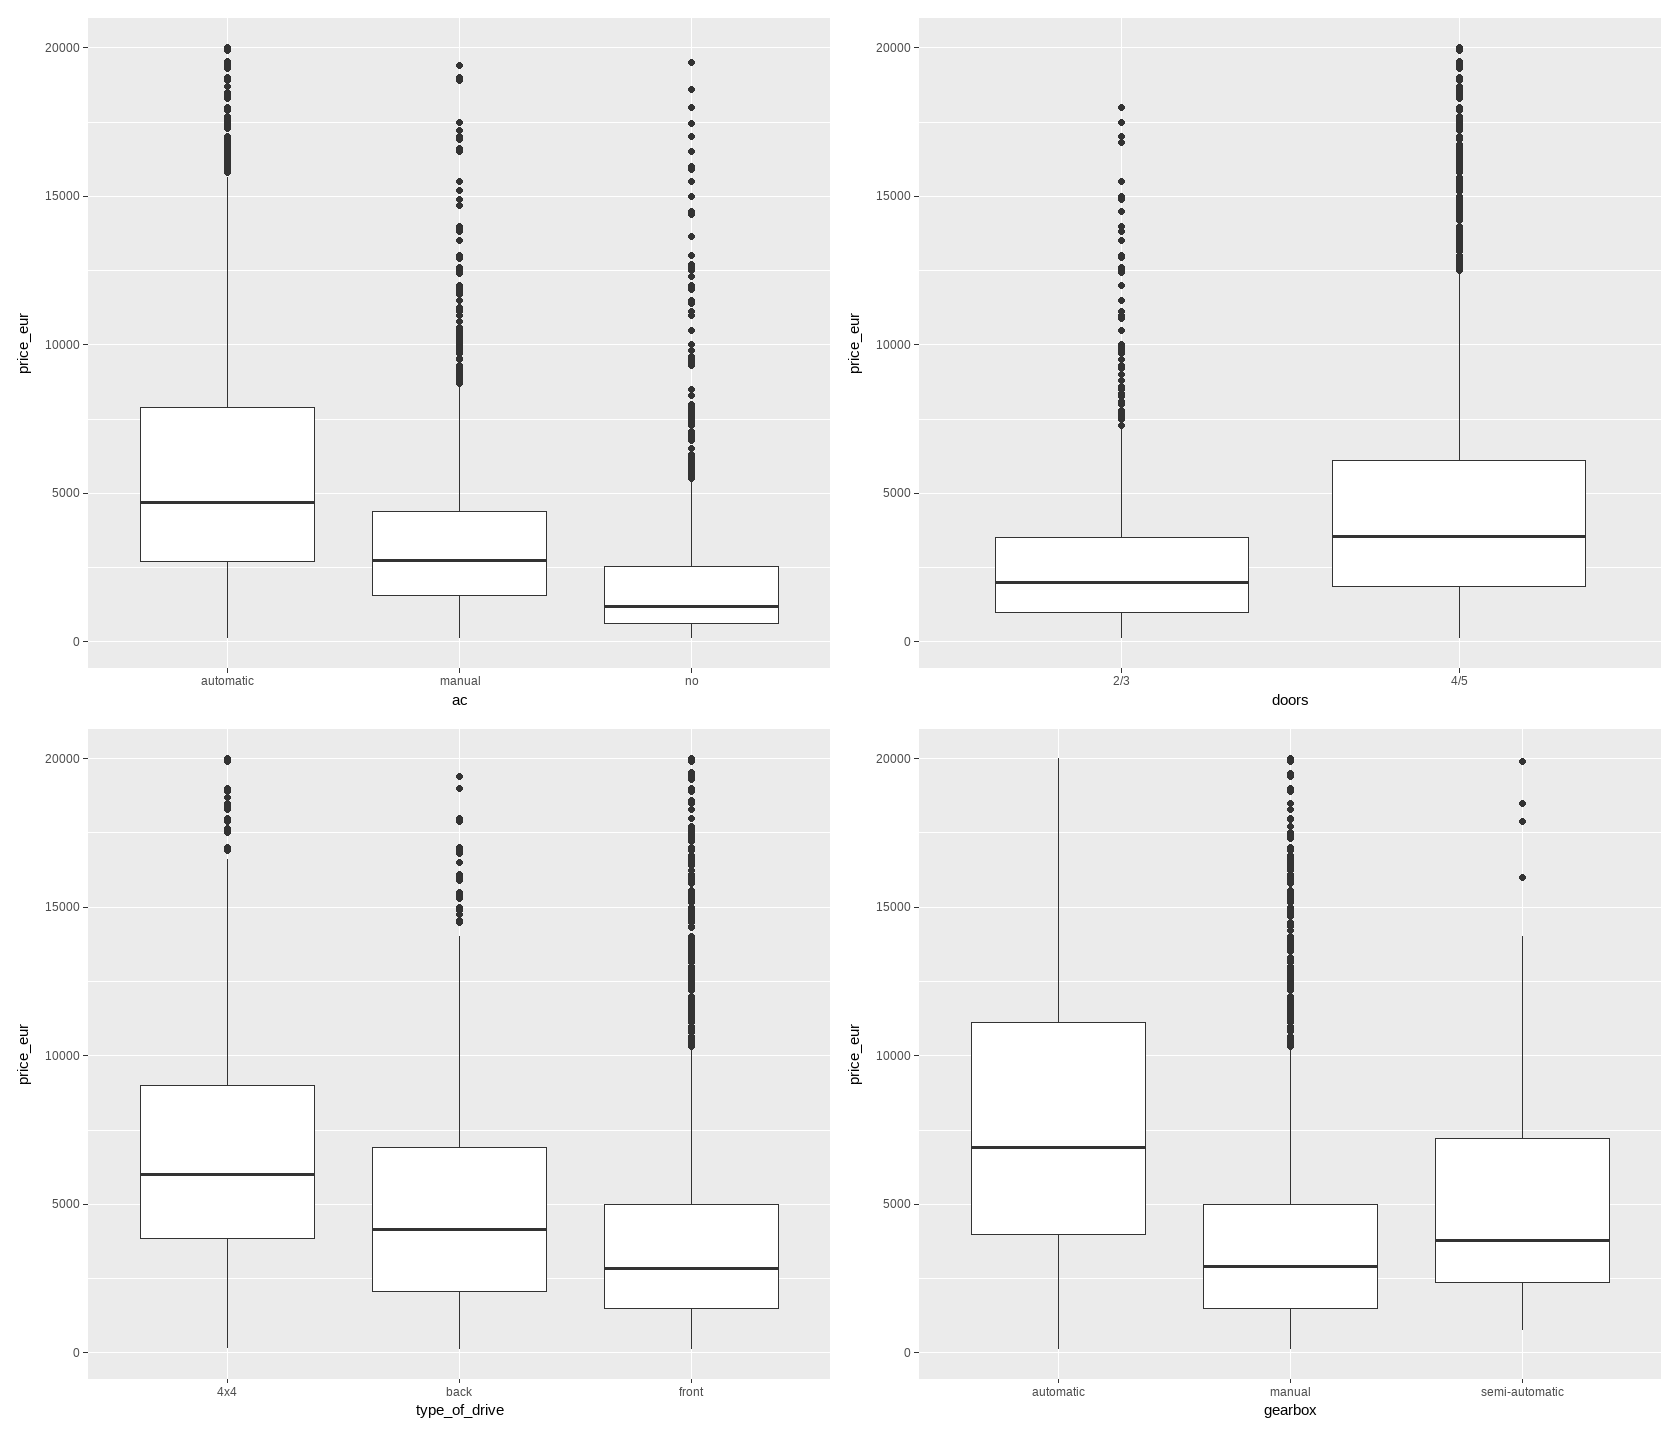

In [46]:
options(repr.plot.width = 14, repr.plot.height = 12)

p1 <- ggplot(cars, aes(x=ac, y=price_eur)) + geom_boxplot()
p2 <- ggplot(cars, aes(x=doors, y=price_eur)) + geom_boxplot()
p3 <- ggplot(cars, aes(x=type_of_drive, y=price_eur)) + geom_boxplot()
p4 <- ggplot(cars, aes(x=gearbox, y=price_eur)) + geom_boxplot()

(p1 + p2) / (p3 + p4)

In [47]:
recipe_data_eng <- recipe(price_eur ~ ., data = cars) %>%
  # Ordinal Encoding (higher number usually means higher price, e.g. automatic is usually the most expensive)
  # The boxplots visualise how the encoding should be done
  step_mutate(
    ac = case_when(
      ac == "no"        ~ 0L,
      ac == "manual"    ~ 1L,
      ac == "automatic" ~ 2L,
    ),
    doors = case_when(
      doors == "2/3"    ~ 3L,
      doors == "4/5"    ~ 5L,
    ),
    type_of_drive = case_when(
      type_of_drive == "front"  ~ 0L,
      type_of_drive == "back"   ~ 1L,
      type_of_drive == "4x4"    ~ 2L,
    ),
    gearbox = case_when(
      gearbox == "manual"         ~ 0L,
      gearbox == "semi-automatic" ~ 1L,
      gearbox == "automatic"      ~ 2L,
    )
  ) %>%
  # Handling missing values (emission_class)
  step_impute_median(all_numeric_predictors()) %>%
  prep()

cars <- bake(recipe_data_eng, new_data = NULL)

head(cars)

id,views,favorite,brand,model,days_passed,year,ac,emission_class,seats,⋯,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds,price_eur
<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>
2,55,0,Alfa Romeo,145,2,2000,1,3,5,⋯,158546,6342,1400,0,3,petrol + gas,hatchback,0,5,1100
3,136,4,Alfa Romeo,145,14,1999,1,3,5,⋯,337000,12962,1910,0,3,diesel,hatchback,0,5,950
4,209,1,Alfa Romeo,146,28,2000,1,3,5,⋯,200000,8000,1600,0,5,petrol + gas,limousine,0,5,500
6,196,2,Alfa Romeo,147,28,2008,0,4,5,⋯,188000,11059,1600,0,5,petrol + gas,hatchback,0,5,2300
7,133,1,Alfa Romeo,147,5,2008,2,4,5,⋯,255000,15000,1929,0,5,diesel,hatchback,0,6,3500
8,290,6,Alfa Romeo,147,6,2008,1,4,5,⋯,214000,12588,1600,0,5,petrol + gas,hatchback,0,5,2150


## Statistics and diagrams

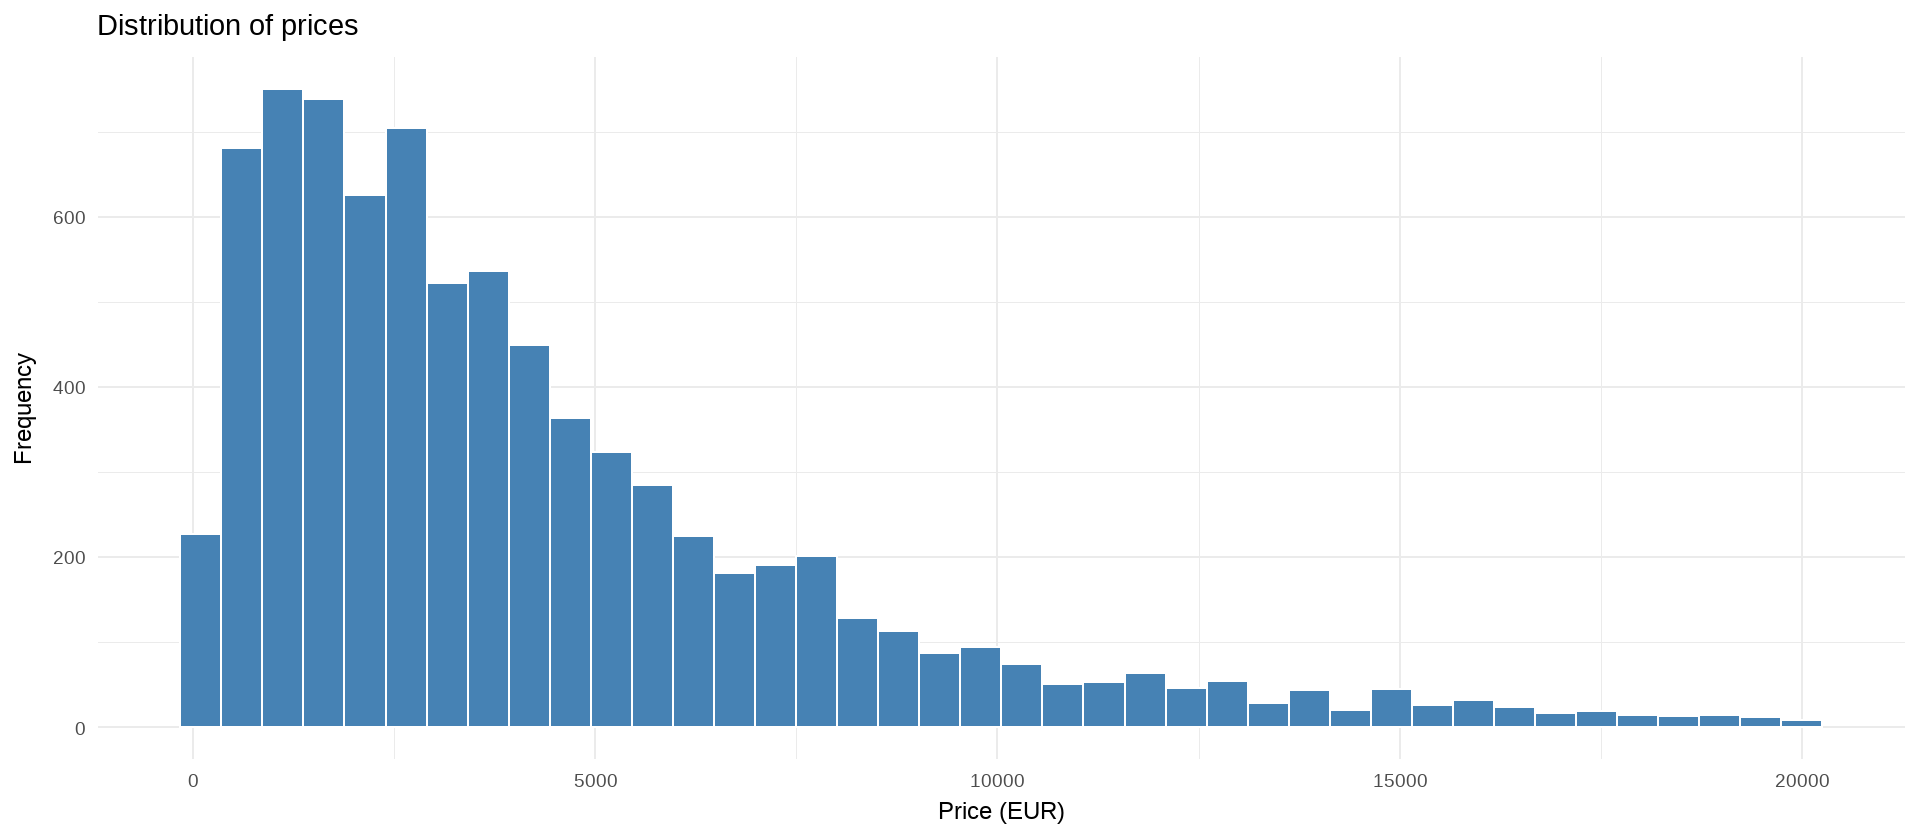

In [52]:
options(repr.plot.width = 16, repr.plot.height = 7)

ggplot(cars, aes(x = price_eur)) +
  geom_histogram(fill = "steelblue", color = "white", bins = 40) +
  theme_minimal(base_size = 18) +
  labs(title = "Distribution of prices", x = "Price (EUR)", y = "Frequency")

`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


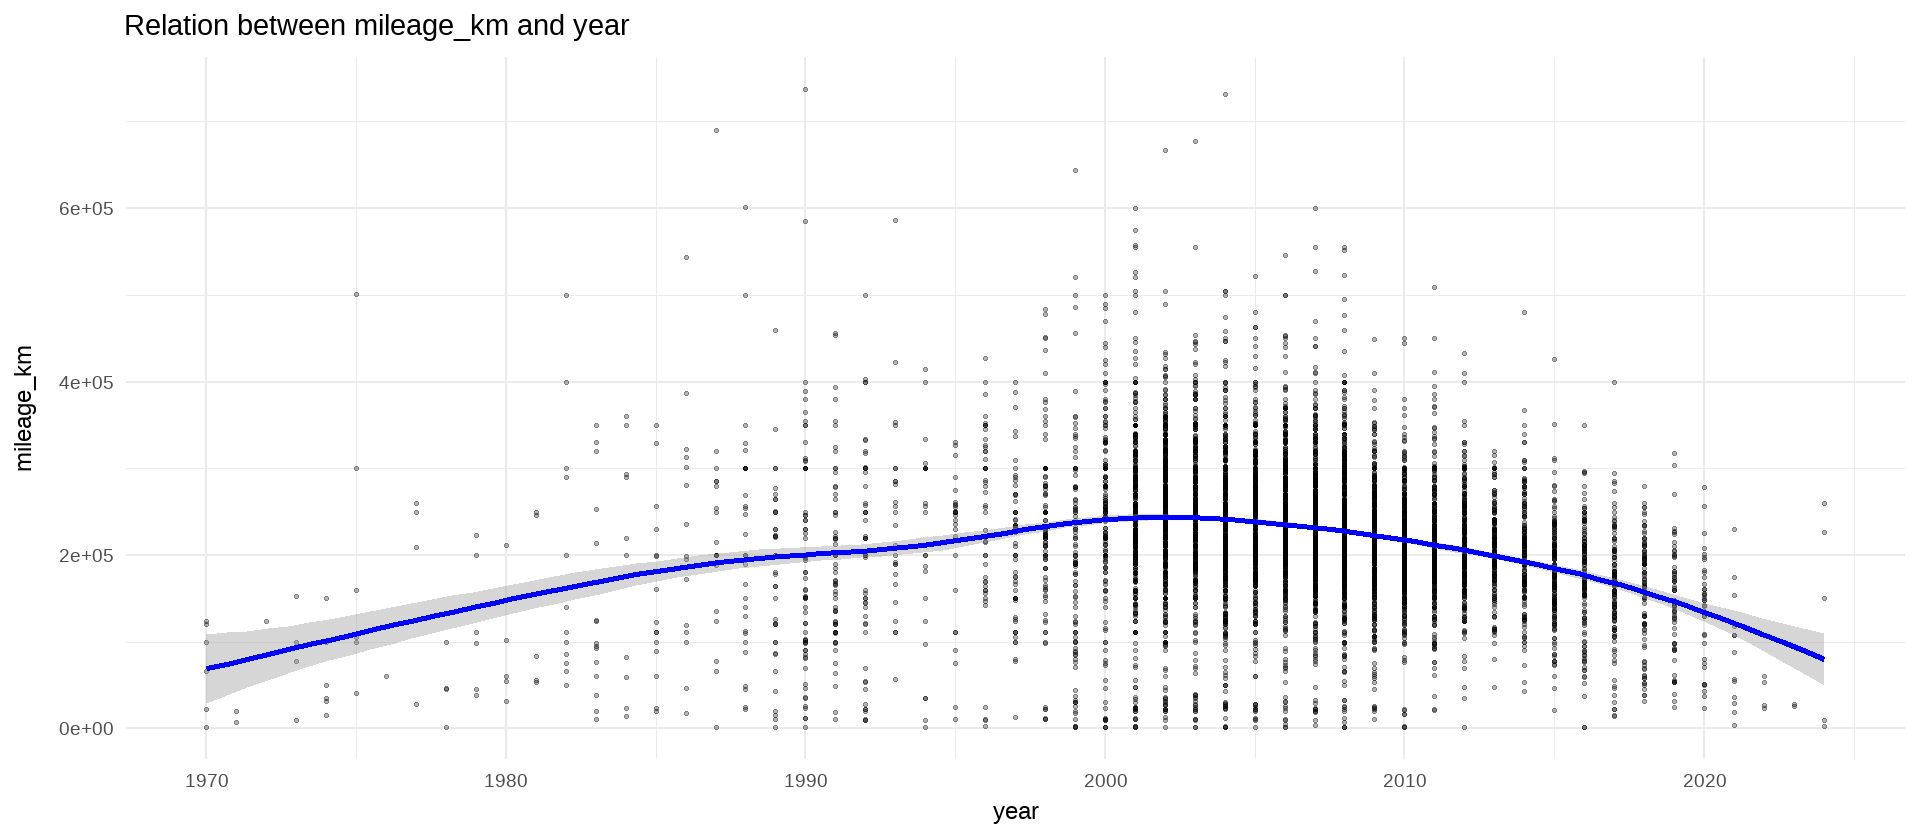

In [54]:
ggplot(cars, aes(x=year, y=mileage_km)) +
  geom_point(color="black", size=0.9, alpha=0.3) +
  geom_smooth(method = "gam", color = "blue", se = TRUE) +
  theme_minimal(base_size = 18) +
  labs(title="Relation between mileage_km and year", x="year", y="mileage_km")

`geom_smooth()` using formula = 'y ~ s(x, bs = "cs")'


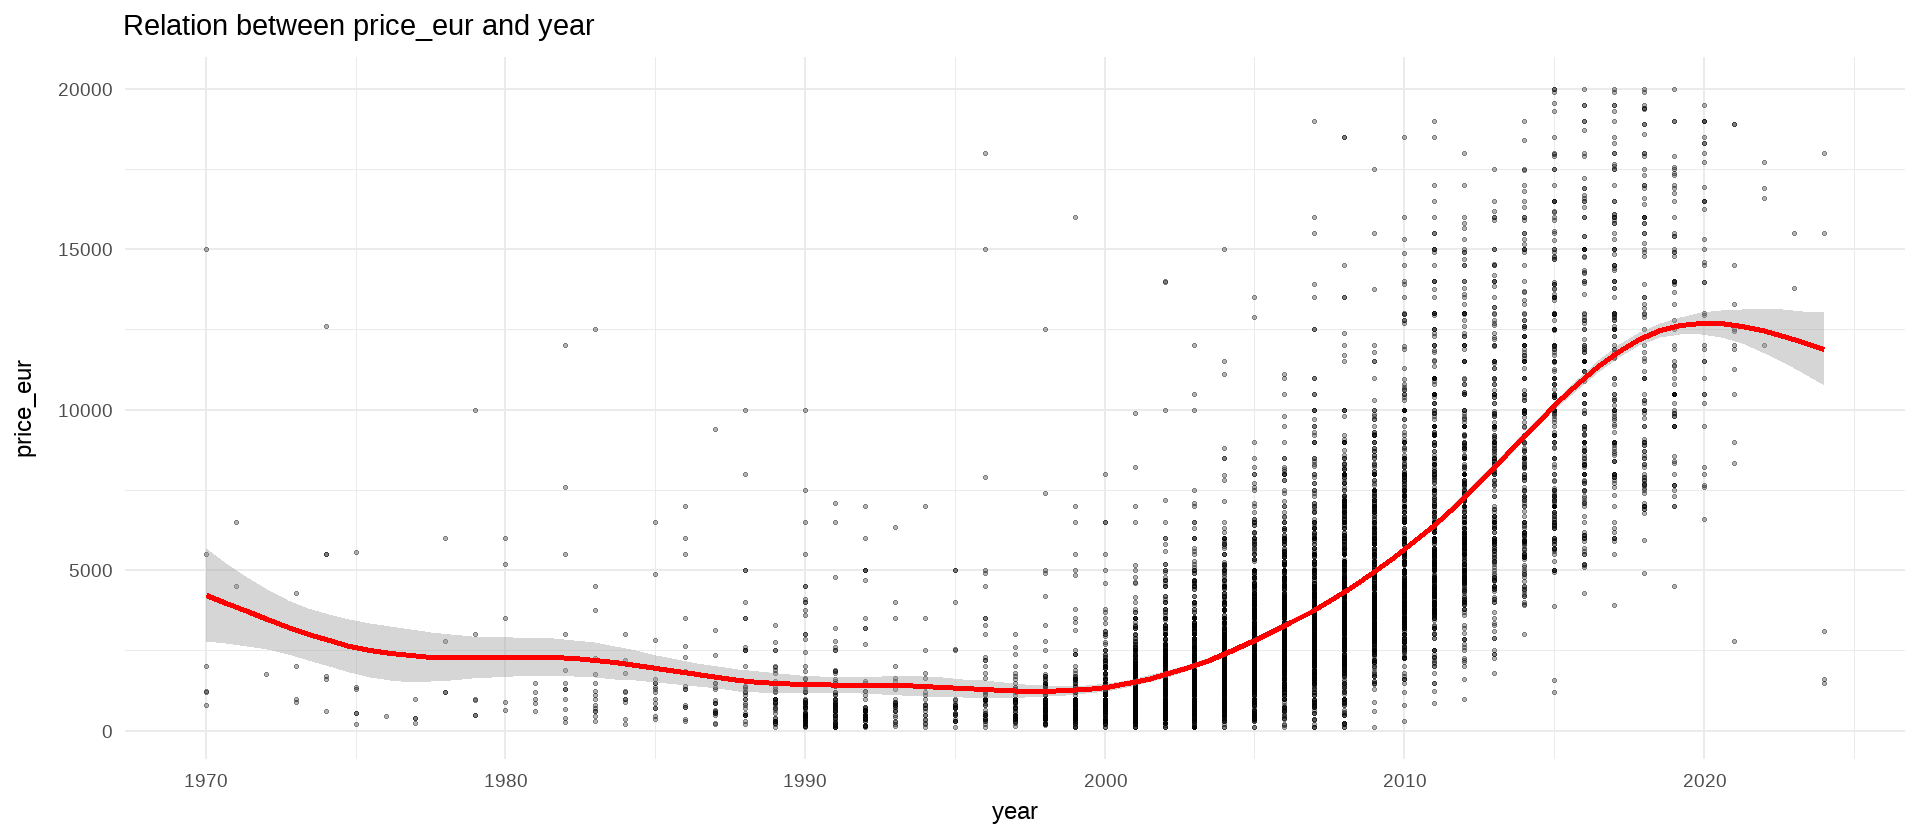

In [55]:
ggplot(cars, aes(x = year, y = price_eur)) +
  geom_point(size = 0.9, alpha = 0.3, color = "black") +
  geom_smooth(method = "gam", color = "red", se = TRUE) +
  theme_minimal(base_size = 18) +
  labs(title = "Relation between price_eur and year")

It's easily visible how much the year correlates with the car's price. It only gets lower after 2020 because cars with high prices were filtered 

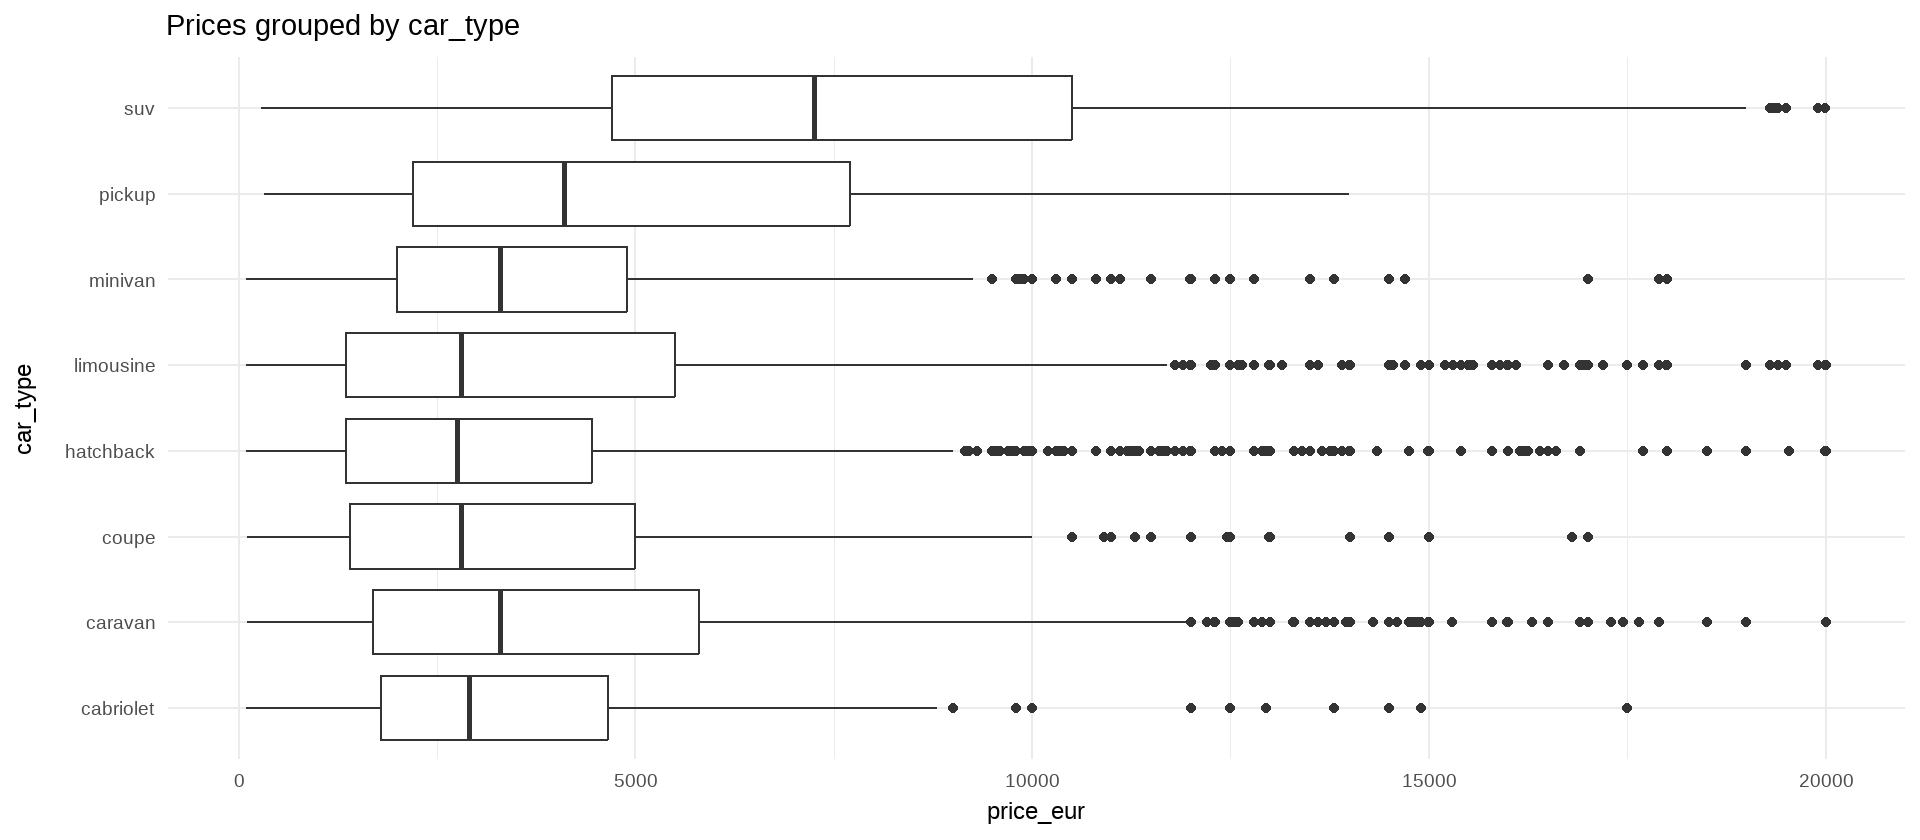

In [57]:
options(repr.plot.width = 16, repr.plot.height = 7)

ggplot(cars, aes(x = car_type, y = price_eur)) +
  geom_boxplot() +
  coord_flip() + 
  theme_minimal(base_size = 18) +
  labs(title = "Prices grouped by car_type")

#### Correlation diagram

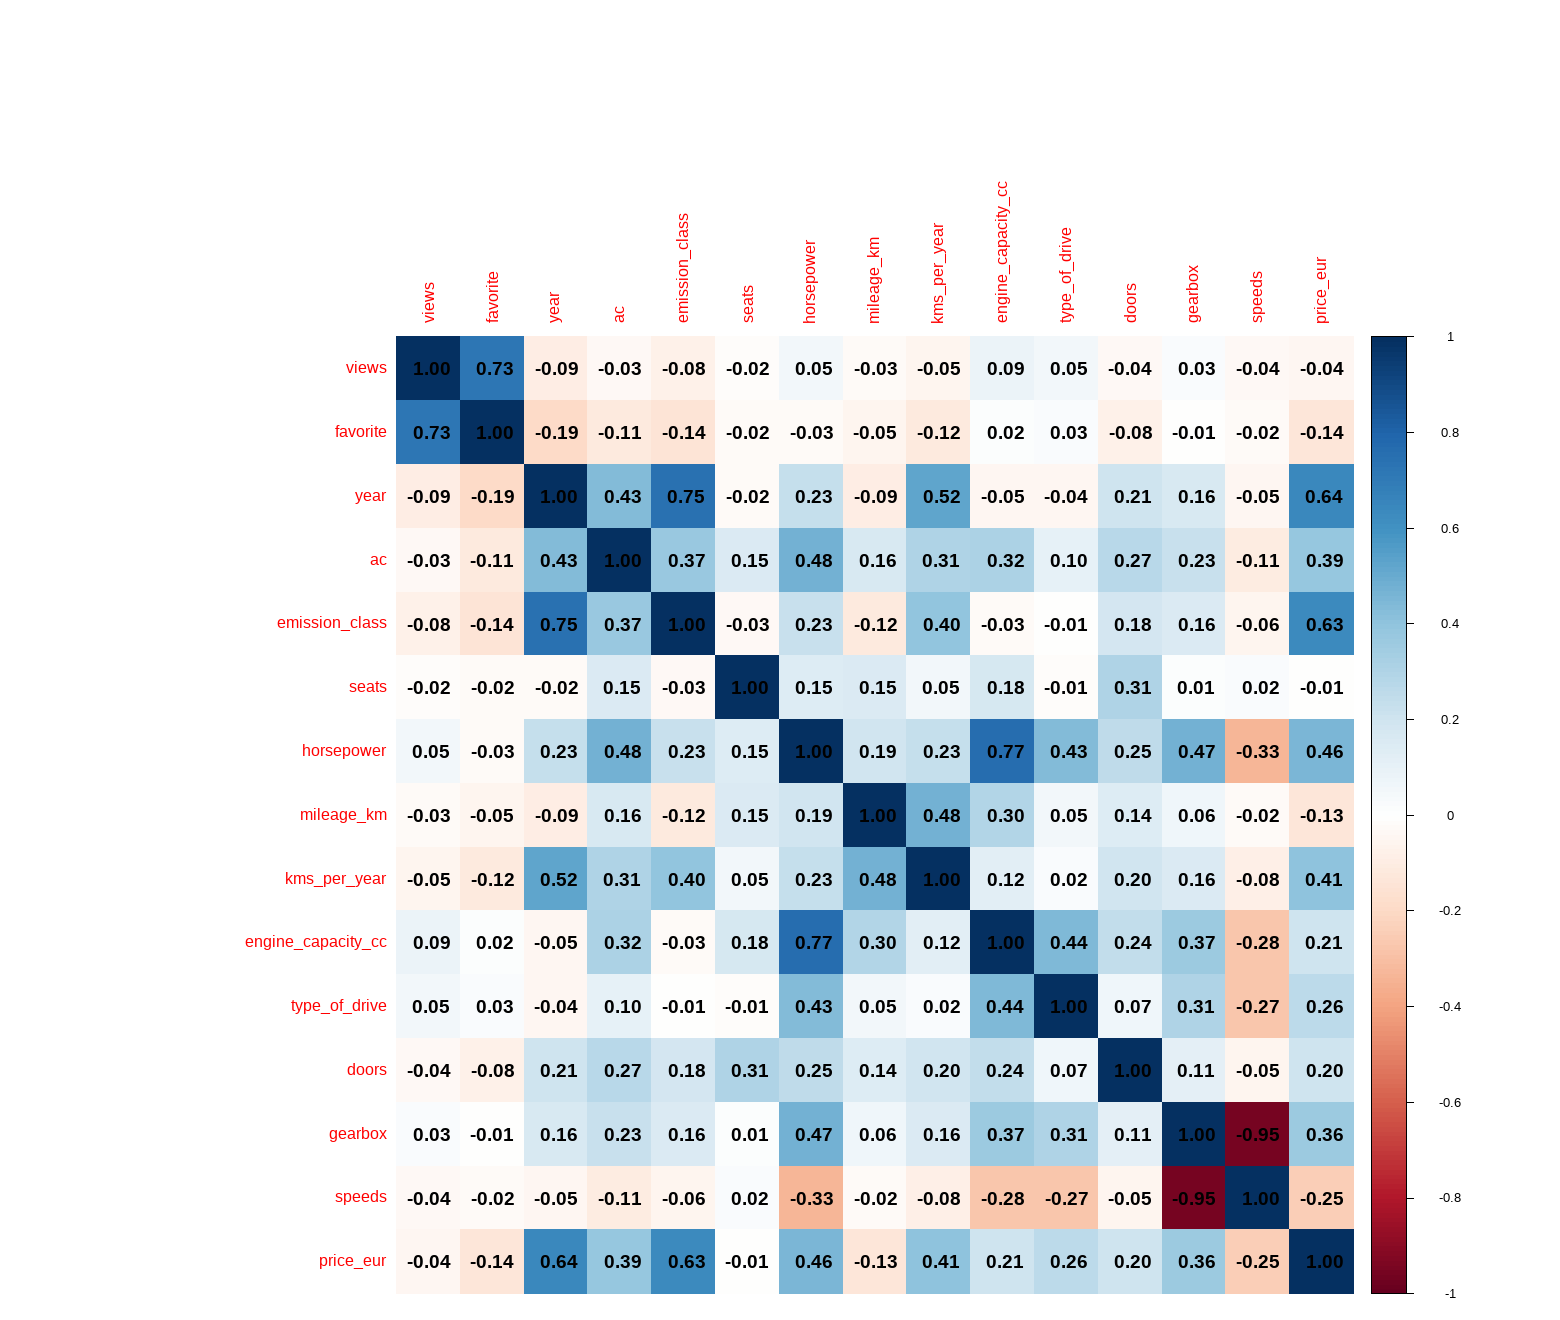

In [67]:
options(repr.plot.width = 13, repr.plot.height = 11)

num_vars <- cars %>% select(where(is.numeric)) %>% 
            select(-id, -days_passed)
M <- cor(num_vars)
corrplot(M, method = "color", addCoef.col = "black", number.cex = 1.2)

Gearbox and speeds have a really strong correlation.

It's possible to remove gearbox column affecting only the few rows with semi-automatic gear.

## Models for predicting price

#### Splitting data into training and testing sets

In [68]:
car_split <- initial_split(cars, prop = 0.8, strata = price_eur)
train_data <- training(car_split)
test_data  <- testing(car_split)

#### Creating recipe for price prediction

In [69]:
recipe_price <- recipe(price_eur ~ ., data = train_data) %>%
  update_role(id, new_role = "ID") %>%
  update_role(views, favorite, days_passed, new_role = "info") %>%
  step_novel(brand, color, fuel, car_type) %>%   
  step_lencode_mixed(model, outcome = vars(price_eur)) %>%
  step_dummy(brand, color, fuel, car_type) %>%
  step_nzv(all_predictors()) %>%
  step_normalize(all_numeric_predictors(), -has_role("info"), -all_outcomes())

## Model 1 - Random forest

#### Basic random forest model

In [70]:
# Creating the basic model
rf_base_spec <- rand_forest(trees = 500) %>%
  set_engine("ranger", num.threads = 12, importance="impurity") %>%
  set_mode("regression")

# Basic workflow
car_base_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(rf_base_spec)

In [71]:
base_res <- last_fit(car_base_wf, car_split)

base_predictions <- base_res %>% 
  collect_predictions()

metrics(base_predictions, truth = price_eur, estimate = .pred)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1477.9519329
rsq,standard,0.8399932
mae,standard,913.9682963


`geom_smooth()` using formula = 'y ~ x'


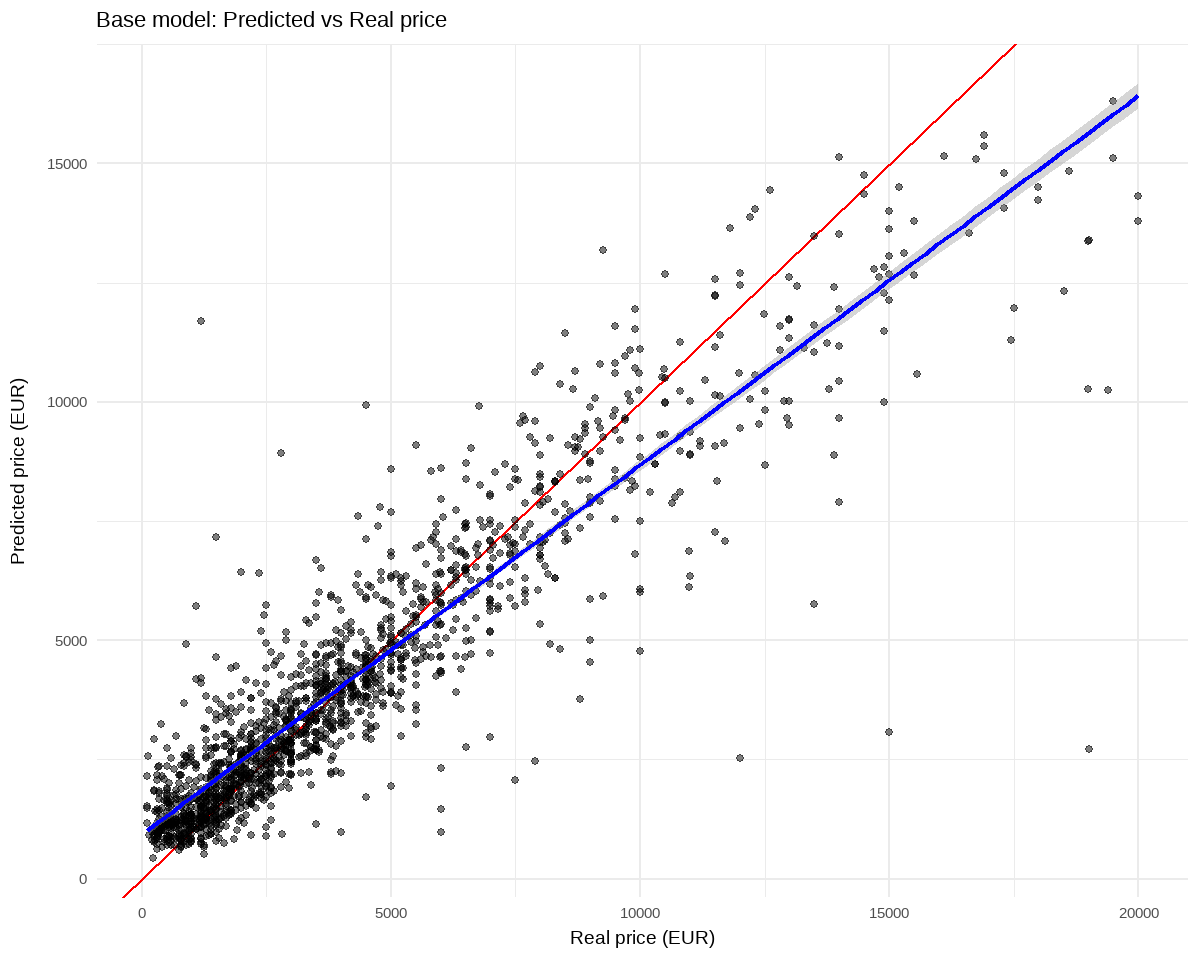

In [81]:
options(repr.plot.width = 10, repr.plot.height = 8)

base_predictions %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  theme_minimal(base_size = 14) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  labs(title = "Base model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

,Variable,Importance
,<chr>,<dbl>
1,year,22653416973
2,model,15846092110
3,emission_class,12165820584
4,kms_per_year,6711297104
5,horsepower,5972817314
6,mileage_km,3518184493
7,engine_capacity_cc,3285724284
8,speeds,2624926113
9,ac,2491735399


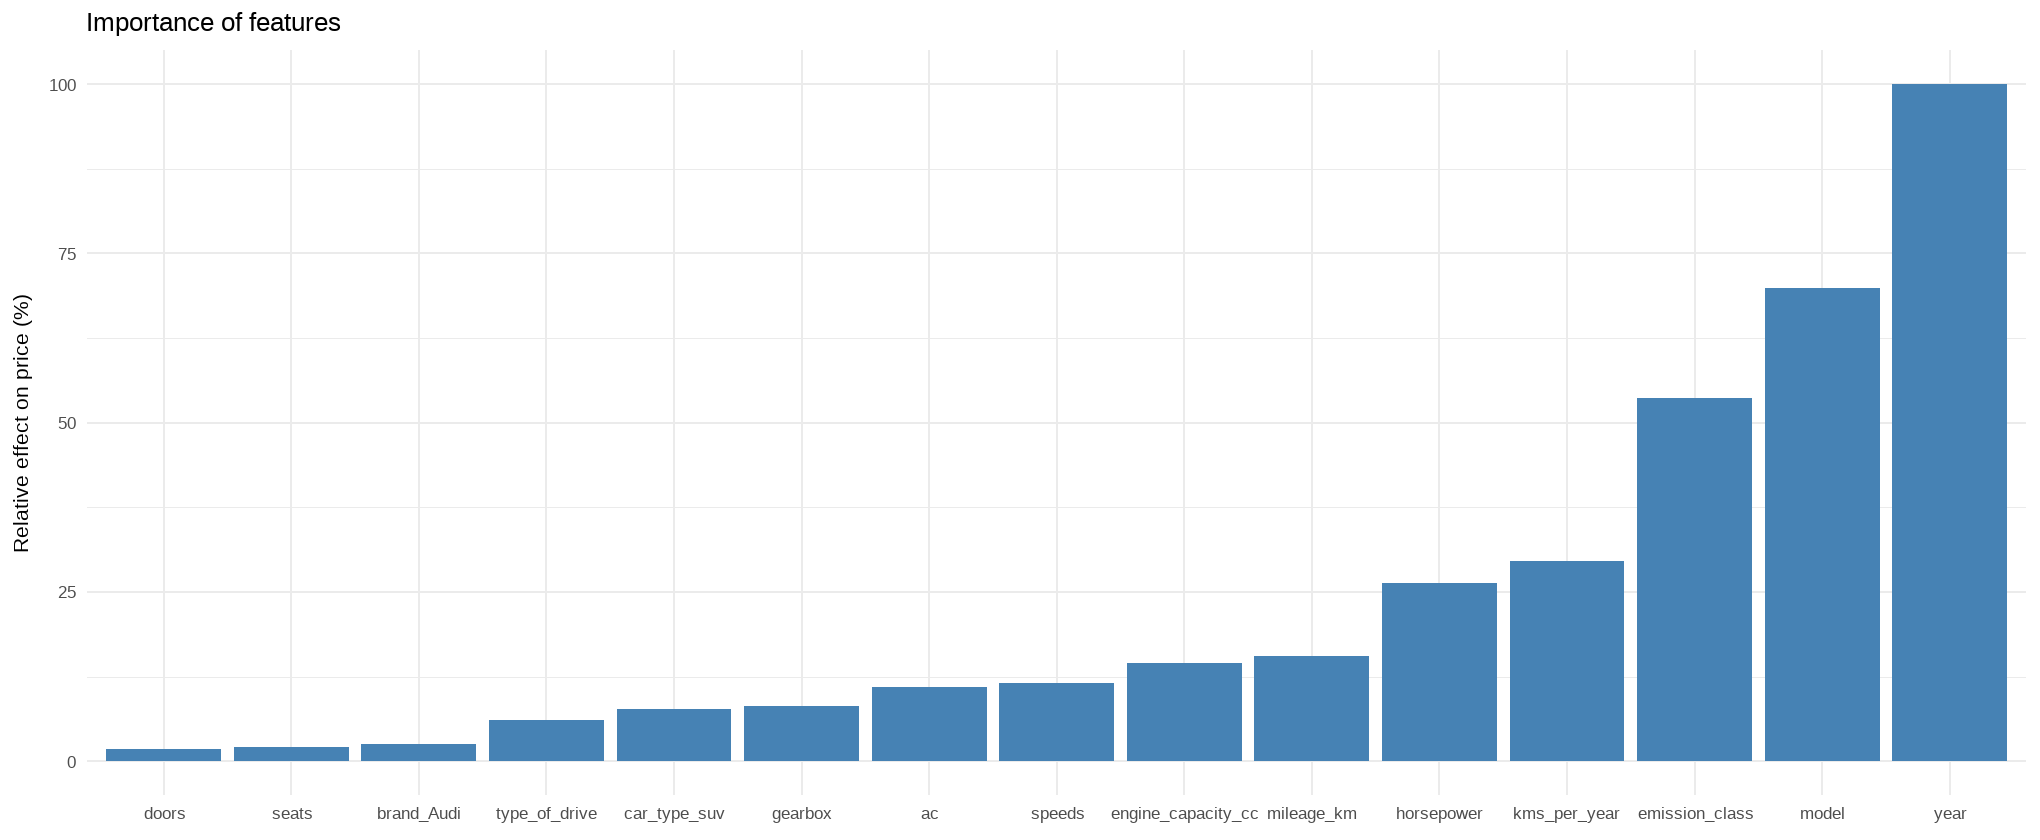

In [106]:
options(repr.plot.width = 17, repr.plot.height = 7)

base_model <- base_res %>% 
  extract_workflow() %>% 
  extract_fit_parsnip()

importance_table <- base_model %>% 
  vi(num_features = 10)

importance_table %>%
  slice_max(Importance, n = 15) %>% 
  mutate(Importance = Importance / max(Importance) * 100) %>%
  ggplot(aes(x = reorder(Variable, Importance), y = Importance)) +
  geom_col(fill = "steelblue") +
  theme_minimal(base_size = 16) +
  labs(title = "Importance of features", x = NULL, y = "Relative effect on price (%)")

importance_table %>% as.data.frame() %>% head(10)

#### Hyperparameter tuning for Random Forest

In [87]:
rf_spec <- rand_forest(
    mtry = tune(),
    min_n = tune(),
    trees = 500
  ) %>%
  set_engine("ranger", num.threads = 12) %>%
  set_mode("regression")

car_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(rf_spec)

In [88]:
car_folds <- vfold_cv(train_data, v = 5, strata = price_eur)

tune_res <- tune_grid(
  car_wf,
  resamples = car_folds,
  grid = 10,
  metrics = metric_set(rmse, rsq, mae),
)

i Creating pre-processing data to finalize 1 unknown parameter: "mtry"



#### Random Forest models with the best RMSE, RSQ and MAE value

In [120]:
cat("Best RMSE:\n")
best_params_rmse <- select_best(tune_res, metric = "rmse")
final_wf_rmse <- finalize_workflow(car_wf, best_params_rmse)
final_res_rmse <- last_fit(final_wf_rmse, car_split) 

final_predictions_rmse <- final_res_rmse %>%
collect_predictions()

best_params_rmse %>% as.data.frame()
metrics(final_predictions_rmse, truth = price_eur, estimate = .pred)

cat("Best RSQ:\n")
best_params_rsq <- select_best(tune_res, metric = "rsq")
final_wf_rsq <- finalize_workflow(car_wf, best_params_rsq)
final_res_rsq <- last_fit(final_wf_rsq, car_split) 

final_predictions_rsq <- final_res_rsq %>%
collect_predictions()

best_params_rsq %>% as.data.frame()
metrics(final_predictions_rsq, truth = price_eur, estimate = .pred)

cat("Best MAE:\n")
best_params_mae <- select_best(tune_res, metric = "mae")
final_wf_mae <- finalize_workflow(car_wf, best_params_mae)
final_rf_res <- last_fit(final_wf_mae, car_split)

final_predictions_rf <- final_rf_res %>%
collect_predictions()

best_params_mae %>% as.data.frame()
metrics(final_predictions_rf, truth = price_eur, estimate = .pred)

Best RMSE:


mtry,min_n,.config
<int>,<int>,<chr>
19,6,pre0_mod06_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1471.9081430
rsq,standard,0.8371388
mae,standard,885.1880328


Best RSQ:


mtry,min_n,.config
<int>,<int>,<chr>
8,2,pre0_mod03_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1472.9666172
rsq,standard,0.8388732
mae,standard,898.4425634


Best MAE:


mtry,min_n,.config
<int>,<int>,<chr>
19,6,pre0_mod06_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1464.3884703
rsq,standard,0.8389632
mae,standard,883.7693198


`geom_smooth()` using formula = 'y ~ x'


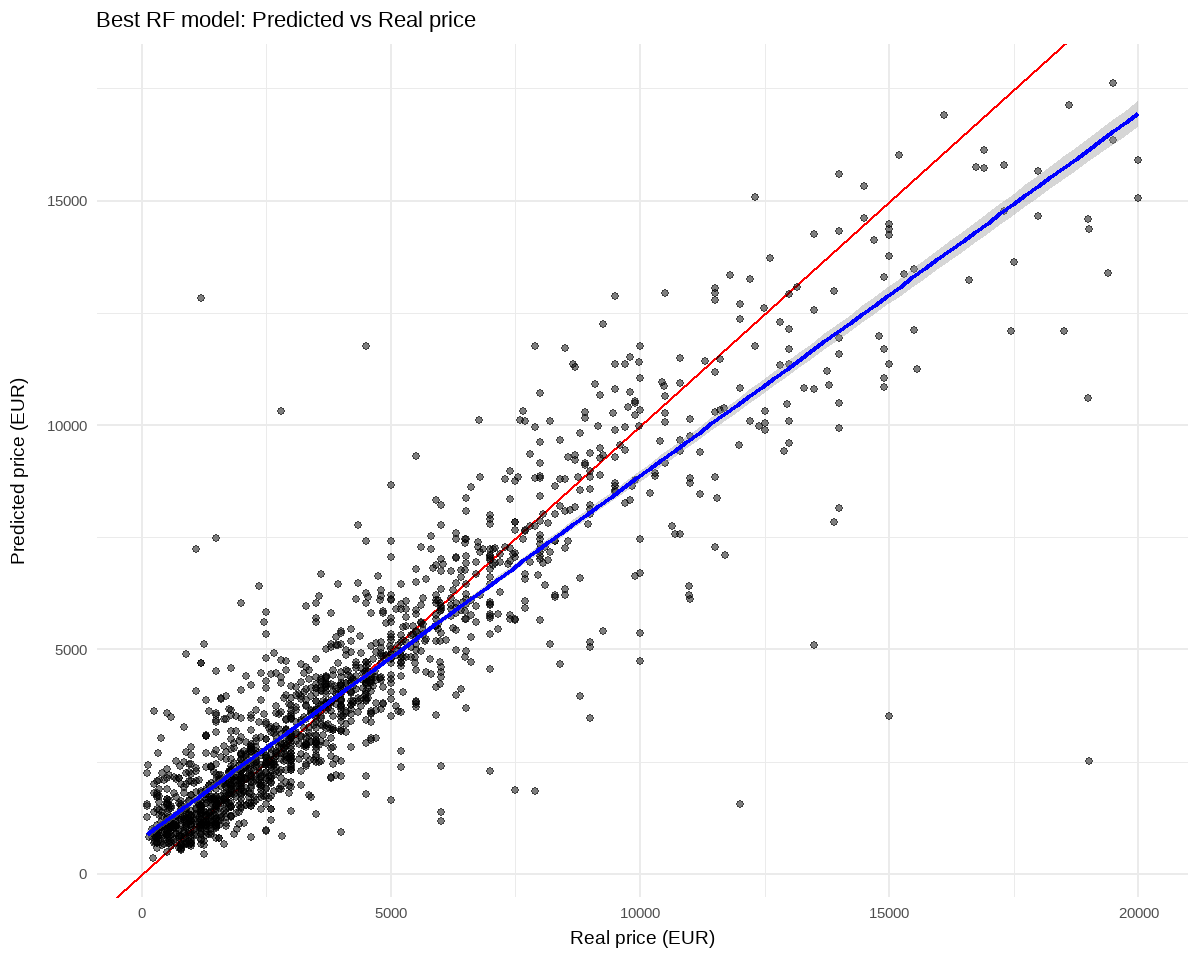

In [90]:
options(repr.plot.width = 10, repr.plot.height = 8)

final_predictions_rf %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  theme_minimal(base_size = 14) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  labs(title = "Best RF model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

#### Worst and best predictions for Random Forest

In [110]:
predictions <- final_res_rmse %>%
  collect_predictions() %>%
  mutate(error = abs(price_eur - .pred))

best_5 <- predictions %>%
  slice_min(order_by = error, n = 5)

worst_5 <- predictions %>%
  slice_max(order_by = error, n = 5)

cat("Best predictions:\n")
best_5 %>% as.data.frame()
cars[best_5$.row, ]

cat("Worst predictions:\n")
worst_5 %>% as.data.frame()
cars[worst_5$.row, ]

Best predictions:


.pred,id,price_eur,.row,.config,error
<dbl>,<chr>,<int>,<int>,<chr>,<dbl>
8050.967,train/test split,8050,7755,pre0_mod0_post0,0.9672000
4800.999,train/test split,4800,434,pre0_mod0_post0,0.9986333
9001.030,train/test split,9000,3709,pre0_mod0_post0,1.0302667
4198.487,train/test split,4200,5699,pre0_mod0_post0,1.5131667
3097.948,train/test split,3100,7604,pre0_mod0_post0,2.0516667


id,views,favorite,brand,model,days_passed,year,ac,emission_class,seats,⋯,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds,price_eur
<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>
8050,718,6,Volkswagen,Tiguan,5,2010,2,4,5,⋯,223000,14867,1400,2,5,petrol,suv,0,6,8050
448,37,0,Audi,A4,14,2006,2,4,5,⋯,218000,11474,1968,0,5,diesel,caravan,2,0,4800
3892,66,0,Mercedes,ML 320,7,2006,2,4,5,⋯,190200,10011,2996,2,5,diesel,suv,2,0,9000
5932,80,0,Renault,Megane,7,2009,2,5,5,⋯,220000,13750,1598,0,3,petrol,coupe,0,6,4200
7882,702,4,Volkswagen,Polo,7,2007,1,4,5,⋯,193815,10768,1198,0,5,petrol,hatchback,0,5,3100


Worst predictions:


.pred,id,price_eur,.row,.config,error
<dbl>,<chr>,<int>,<int>,<chr>,<dbl>
2494.250,train/test split,19000,5880,pre0_mod0_post0,16505.750
12876.158,train/test split,1200,3024,pre0_mod0_post0,11676.158
3570.690,train/test split,15000,981,pre0_mod0_post0,11429.310
1392.149,train/test split,11999,146,pre0_mod0_post0,10606.851
10495.795,train/test split,18999,3376,pre0_mod0_post0,8503.205


id,views,favorite,brand,model,days_passed,year,ac,emission_class,seats,⋯,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds,price_eur
<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>
6115,14,0,Renault,Scenic,0,2007,2,4,5,⋯,230000,12778,1500,0,5,diesel,limousine,0,6,19000
3151,6681,10,Jaguar,XF,7,2010,2,5,5,⋯,120000,8000,3000,1,5,diesel,limousine,2,0,1200
1040,119,2,BMW,320,14,2004,0,4,5,⋯,25618,1220,1900,0,5,petrol,limousine,0,5,15000
152,470,0,Audi,80,21,1982,0,1,5,⋯,50000,1163,1982,0,5,petrol,limousine,0,5,11999
3529,220,1,Mercedes,200,4,2016,1,6,5,⋯,239000,26556,1600,1,5,diesel,limousine,0,6,18999


## Model 2 - XGBoost

In [111]:
xgb_spec <- boost_tree() %>% 
  set_engine("xgboost") %>% 
  set_mode("regression")

xgb_workflow <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(xgb_spec)

In [113]:
xgb_fit <- xgb_workflow %>%
  fit(data = train_data)

base_results <- test_data %>%
  select(price_eur) %>%
  bind_cols(predict(xgb_fit, test_data))

metrics_results <- base_results %>%
  metrics(truth = price_eur, estimate = .pred)

metrics_results %>% as.data.frame()

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1493.6124589
rsq,standard,0.8320123
mae,standard,923.6009887


`geom_smooth()` using formula = 'y ~ x'


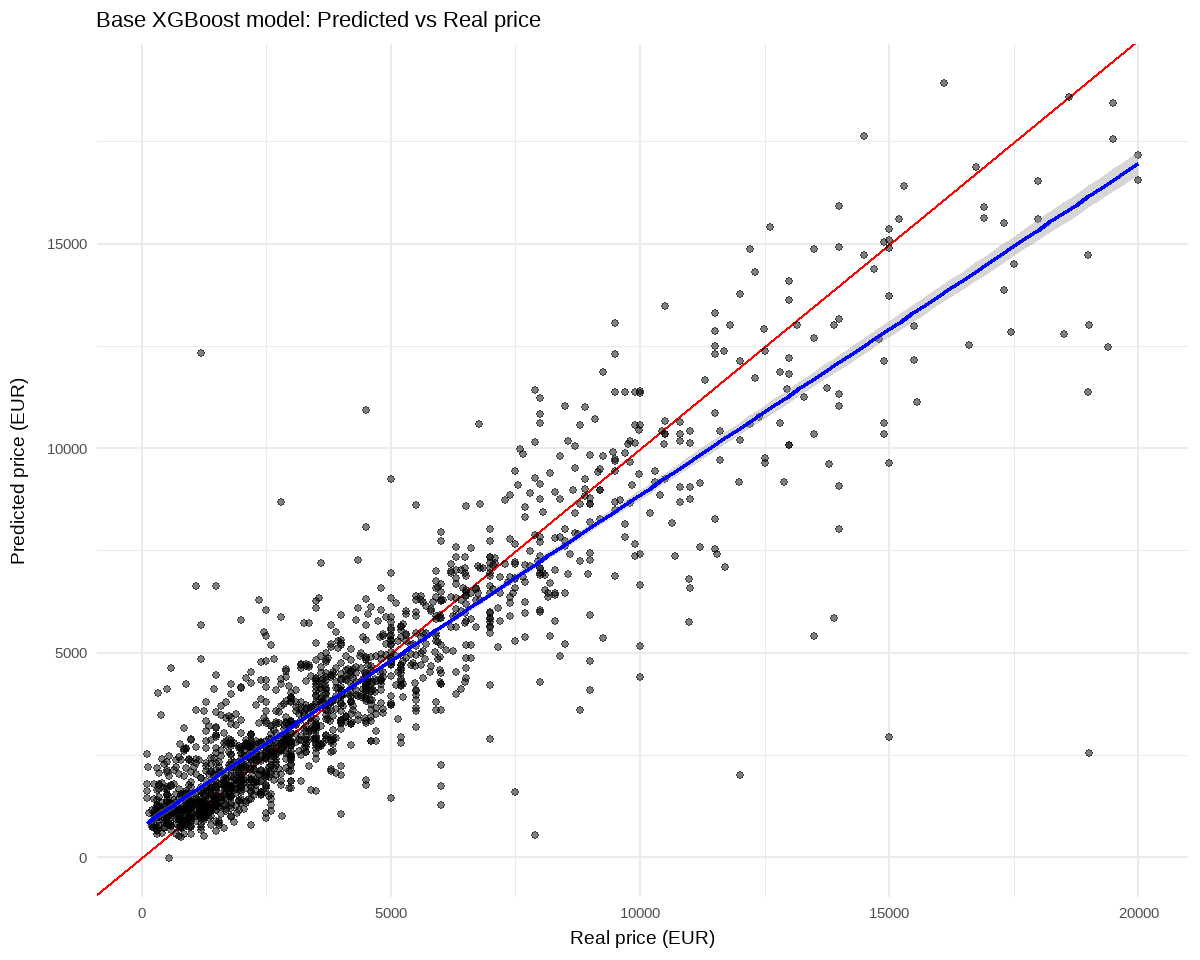

In [114]:
options(repr.plot.width = 10, repr.plot.height = 8)

base_results %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  theme_minimal(base_size = 14) +
  labs(title = "Base XGBoost model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

#### Hyperparameter tuning for XGBoost

In [115]:
cores <- parallel::detectCores(logical = FALSE)
cl <- makePSOCKcluster(cores - 1)
registerDoParallel(cl)

car_folds <- vfold_cv(train_data, v = 5, strata = price_eur)

xgb_tune_spec <- boost_tree(
  trees = 500,
  tree_depth = tune(),
  min_n = tune(),
  learn_rate = tune(),
  loss_reduction = tune()
) %>%
  set_engine("xgboost", nthread = 12) %>%
  set_mode("regression")

xgb_tune_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(xgb_tune_spec)

xgb_rs <- tune_grid(
  xgb_tune_wf,
  resamples = car_folds,
  grid = 10,
  metrics = metric_set(rmse, rsq, mae),
  control = control_grid(save_pred = TRUE)
)

stopCluster(cl)

#### XGBoost Models with the best RMSE, RSQ and MAE values

In [119]:
cat("Best RMSE:\n")

best_xgb_params <- select_best(xgb_rs, metric = "rmse")
final_xgb_wf <- finalize_workflow(xgb_tune_wf, best_xgb_params)
final_xgb_res <- last_fit(final_xgb_wf, car_split)

final_predictions_xgb <- final_xgb_res %>%
  collect_predictions()

best_xgb_params %>% as.data.frame()
metrics(final_predictions_xgb, truth = price_eur, estimate = .pred)

cat("Best RSQ:\n")

best_xgb_params <- select_best(xgb_rs, metric = "rsq")
final_xgb_wf <- finalize_workflow(xgb_tune_wf, best_xgb_params)
final_xgb_res <- last_fit(final_xgb_wf, car_split)

final_predictions_xgb <- final_xgb_res %>%
  collect_predictions()

best_xgb_params %>% as.data.frame()
metrics(final_predictions_xgb, truth = price_eur, estimate = .pred)

cat("Best MAE:\n")

best_xgb_params <- select_best(xgb_rs, metric = "mae")
final_xgb_wf <- finalize_workflow(xgb_tune_wf, best_xgb_params)
final_xgb_res <- last_fit(final_xgb_wf, car_split)

final_predictions_xgb <- final_xgb_res %>%
  collect_predictions()

best_xgb_params %>% as.data.frame()
metrics(final_predictions_xgb, truth = price_eur, estimate = .pred)

Best RMSE:


min_n,tree_depth,learn_rate,loss_reduction,.config
<int>,<int>,<dbl>,<dbl>,<chr>
35,7,0.02448437,1e-10,pre0_mod09_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1438.5544197
rsq,standard,0.8438222
mae,standard,869.2122367


Best RSQ:


min_n,tree_depth,learn_rate,loss_reduction,.config
<int>,<int>,<dbl>,<dbl>,<chr>
35,7,0.02448437,1e-10,pre0_mod09_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1438.5544197
rsq,standard,0.8438222
mae,standard,869.2122367


Best MAE:


min_n,tree_depth,learn_rate,loss_reduction,.config
<int>,<int>,<dbl>,<dbl>,<chr>
35,7,0.02448437,1e-10,pre0_mod09_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1438.5544197
rsq,standard,0.8438222
mae,standard,869.2122367


`geom_smooth()` using formula = 'y ~ x'


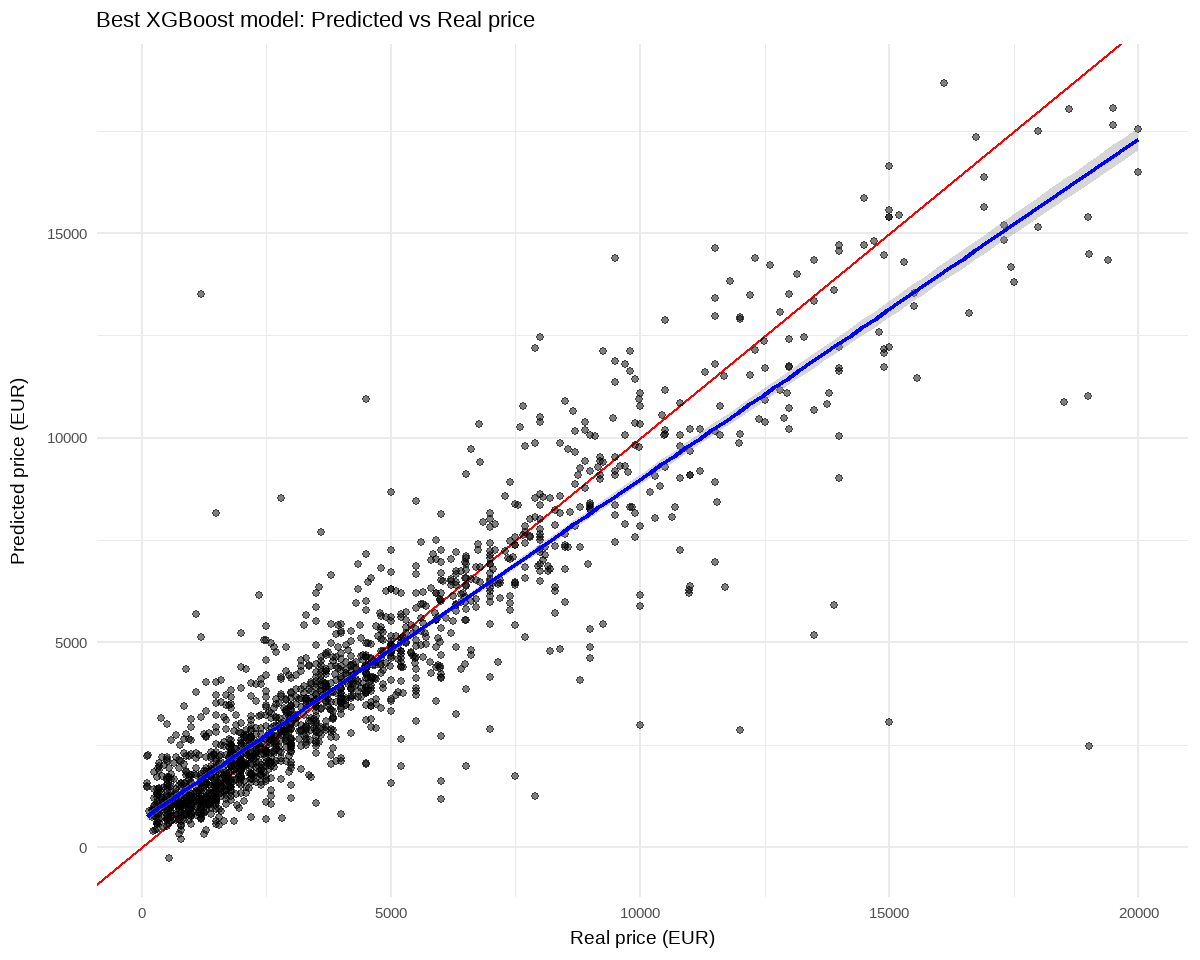

In [117]:
final_predictions_xgb %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  theme_minimal(base_size = 14) +
  labs(title = "Best XGBoost model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

#### Worst and best predictions

In [118]:
predictions <- final_xgb_res %>%
  collect_predictions() %>%
  mutate(error = abs(price_eur - .pred))

best_5 <- predictions %>%
  slice_min(order_by = error, n = 5)

worst_5 <- predictions %>%
  slice_max(order_by = error, n = 5)

cat("Best predictions:\n")
best_5 %>% as.data.frame()
cars[best_5$.row, ]

cat("Worst predictions:\n")
worst_5 %>% as.data.frame()
cars[worst_5$.row, ]

Best predictions:


.pred,id,price_eur,.row,.config,error
<dbl>,<chr>,<int>,<int>,<chr>,<dbl>
1499.5820,train/test split,1500,1684,pre0_mod0_post0,0.4179688
1399.0560,train/test split,1400,2333,pre0_mod0_post0,0.9439697
1998.8896,train/test split,2000,5068,pre0_mod0_post0,1.1103516
947.0153,train/test split,950,2299,pre0_mod0_post0,2.9846802
1903.2155,train/test split,1900,2205,pre0_mod0_post0,3.2154541


id,views,favorite,brand,model,days_passed,year,ac,emission_class,seats,⋯,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds,price_eur
<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>
1777,71,1,Citroen,Xsara Picasso,14,2004,2,3,5,⋯,270000,12857,1800,0,5,petrol + gas,limousine,0,5,1500
2437,104,1,Fiat,Scudo,14,1998,0,2,5,⋯,360000,13333,1600,0,5,petrol + gas,minivan,0,5,1400
5285,118,4,Peugeot,307,7,2006,1,4,5,⋯,230000,12105,1400,0,5,petrol,caravan,0,5,2000
2402,284,8,Fiat,Punto,14,2000,0,3,5,⋯,212817,8513,1200,0,3,petrol,hatchback,0,5,950
2307,64,0,Fiat,Punto,2,2006,1,4,5,⋯,239000,12579,1242,0,5,petrol,hatchback,0,5,1900


Worst predictions:


.pred,id,price_eur,.row,.config,error
<dbl>,<chr>,<int>,<int>,<chr>,<dbl>
2474.068,train/test split,19000,5880,pre0_mod0_post0,16525.932
13518.608,train/test split,1200,3024,pre0_mod0_post0,12318.608
3055.833,train/test split,15000,981,pre0_mod0_post0,11944.167
2856.287,train/test split,11999,146,pre0_mod0_post0,9142.713
5185.567,train/test split,13500,6610,pre0_mod0_post0,8314.433


id,views,favorite,brand,model,days_passed,year,ac,emission_class,seats,⋯,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds,price_eur
<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>
6115,14,0,Renault,Scenic,0,2007,2,4,5,⋯,230000,12778,1500,0,5,diesel,limousine,0,6,19000
3151,6681,10,Jaguar,XF,7,2010,2,5,5,⋯,120000,8000,3000,1,5,diesel,limousine,2,0,1200
1040,119,2,BMW,320,14,2004,0,4,5,⋯,25618,1220,1900,0,5,petrol,limousine,0,5,15000
152,470,0,Audi,80,21,1982,0,1,5,⋯,50000,1163,1982,0,5,petrol,limousine,0,5,11999
6866,399,1,Toyota,Land Cruiser FJ120,7,2005,2,4,8,⋯,350000,17500,2999,2,5,diesel,suv,2,0,13500


## Model 3 - SVM

In [121]:
svm_base_spec <- svm_rbf(cost = 10, margin = 0.1) %>%
  set_engine("kernlab") %>%
  set_mode("regression")

svm_base_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(svm_base_spec)

svm_base_res <- last_fit(svm_base_wf, car_split)

svm_base_predictions <- svm_base_res %>% 
  collect_predictions()

metrics(svm_base_predictions, truth = price_eur, estimate = .pred)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1484.1702548
rsq,standard,0.8341919
mae,standard,932.8706847


It works, but it's slower compared to the other models

`geom_smooth()` using formula = 'y ~ x'


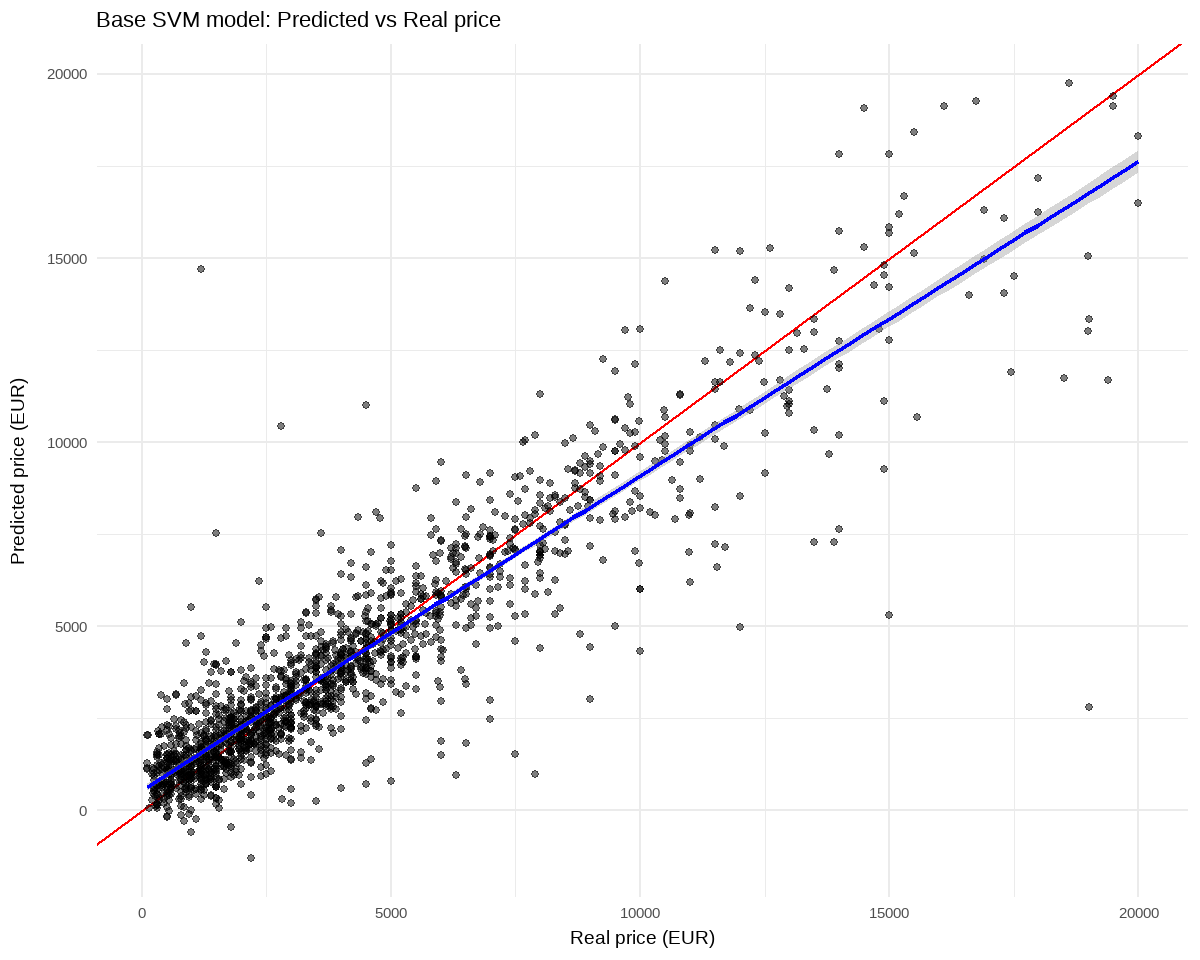

In [122]:
svm_base_predictions %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  theme_minimal(base_size = 14) +
  labs(title = "Base SVM model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

#### Hyperparameter tuning for SVM

In [123]:
cores <- parallel::detectCores(logical = FALSE)
cl <- makePSOCKcluster(cores - 1)
registerDoParallel(cl)

svm_spec <- svm_rbf(
    cost = tune(), 
    rbf_sigma = tune(),
    margin = tune()
  ) %>%
  set_engine("kernlab") %>%
  set_mode("regression")

svm_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(svm_spec)

train_tiny <- train_data %>% slice_sample(prop = 0.3)
# Only using 30% of the training dataset, it makes the tuning lot faster
car_folds <- vfold_cv(train_tiny, v = 5, strata = price_eur)

In [124]:
svm_tune_res <- tune_grid(
  svm_wf,
  resamples = car_folds,
  grid = 10, 
  metrics = metric_set(rmse, rsq, mae),
  control = control_grid(save_pred = TRUE, parallel_over = "everything")
)

svm_tune_res %>% collect_metrics() %>% head(10)

stopCluster(cl)
registerDoSEQ()

cost,rbf_sigma,margin,.metric,.estimator,mean,n,std_err,.config
<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
9.765625e-04,2.154435e-07,0.08888889,mae,standard,2.677175e+03,5,4.812787e+01,pre0_mod01_post0
9.765625e-04,2.154435e-07,0.08888889,rmse,standard,3.971283e+03,5,9.014922e+01,pre0_mod01_post0
9.765625e-04,2.154435e-07,0.08888889,rsq,standard,5.878548e-01,5,2.561965e-02,pre0_mod01_post0
3.100393e-03,7.742637e-02,0.11111111,mae,standard,2.601067e+03,5,4.982676e+01,pre0_mod02_post0
3.100393e-03,7.742637e-02,0.11111111,rmse,standard,3.895886e+03,5,9.322041e+01,pre0_mod02_post0
3.100393e-03,7.742637e-02,0.11111111,rsq,standard,3.764250e-01,5,2.418834e-02,pre0_mod02_post0
9.843133e-03,1.668101e-08,0.17777778,mae,standard,2.677095e+03,5,4.807907e+01,pre0_mod03_post0
9.843133e-03,1.668101e-08,0.17777778,rmse,standard,3.964994e+03,5,8.808721e+01,pre0_mod03_post0
9.843133e-03,1.668101e-08,0.17777778,rsq,standard,5.929783e-01,5,2.549194e-02,pre0_mod03_post0


In [125]:
cat("Best RMSE:\n")

best_svm_params <- select_best(svm_tune_res, metric = "rmse")
final_svm_wf <- finalize_workflow(svm_wf, best_svm_params)
final_svm_res <- last_fit(final_svm_wf, car_split)

final_predictions_svm <- final_svm_res %>%
  collect_predictions()

best_svm_params %>% as.data.frame()
metrics(final_predictions_svm, truth = price_eur, estimate = .pred)

cat("Best RSQ:\n")
best_svm_params <- select_best(svm_tune_res, metric = "rsq")
final_svm_wf <- finalize_workflow(svm_wf, best_svm_params)
final_svm_res <- last_fit(final_svm_wf, car_split)

final_predictions_svm <- final_svm_res %>%
  collect_predictions()

best_svm_params %>% as.data.frame()
metrics(final_predictions_svm, truth = price_eur, estimate = .pred)

cat("Best MAE:\n")
best_svm_params <- select_best(svm_tune_res, metric = "mae")
final_svm_wf <- finalize_workflow(svm_wf, best_svm_params)
final_svm_res <- last_fit(final_svm_wf, car_split)

final_predictions_svm <- final_svm_res %>%
  collect_predictions()

best_svm_params %>% as.data.frame()
metrics(final_predictions_svm, truth = price_eur, estimate = .pred)

Best RMSE:


cost,rbf_sigma,margin,.config
<dbl>,<dbl>,<dbl>,<chr>
0.3149803,0.005994843,0.2,pre0_mod06_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1653.6233423
rsq,standard,0.7972112
mae,standard,1006.2312626


Best RSQ:


cost,rbf_sigma,margin,.config
<dbl>,<dbl>,<dbl>,<chr>
0.3149803,0.005994843,0.2,pre0_mod06_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1653.6233423
rsq,standard,0.7972112
mae,standard,1006.2312626


Best MAE:


cost,rbf_sigma,margin,.config
<dbl>,<dbl>,<dbl>,<chr>
0.3149803,0.005994843,0.2,pre0_mod06_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1653.6233423
rsq,standard,0.7972112
mae,standard,1006.2312626


`geom_smooth()` using formula = 'y ~ x'


<ggplot2::labels> List of 3
 $ x    : chr "Real price (EUR)"
 $ y    : chr "Predicted price (EUR)"
 $ title: chr "Best SVM model: Predicted vs Real price"

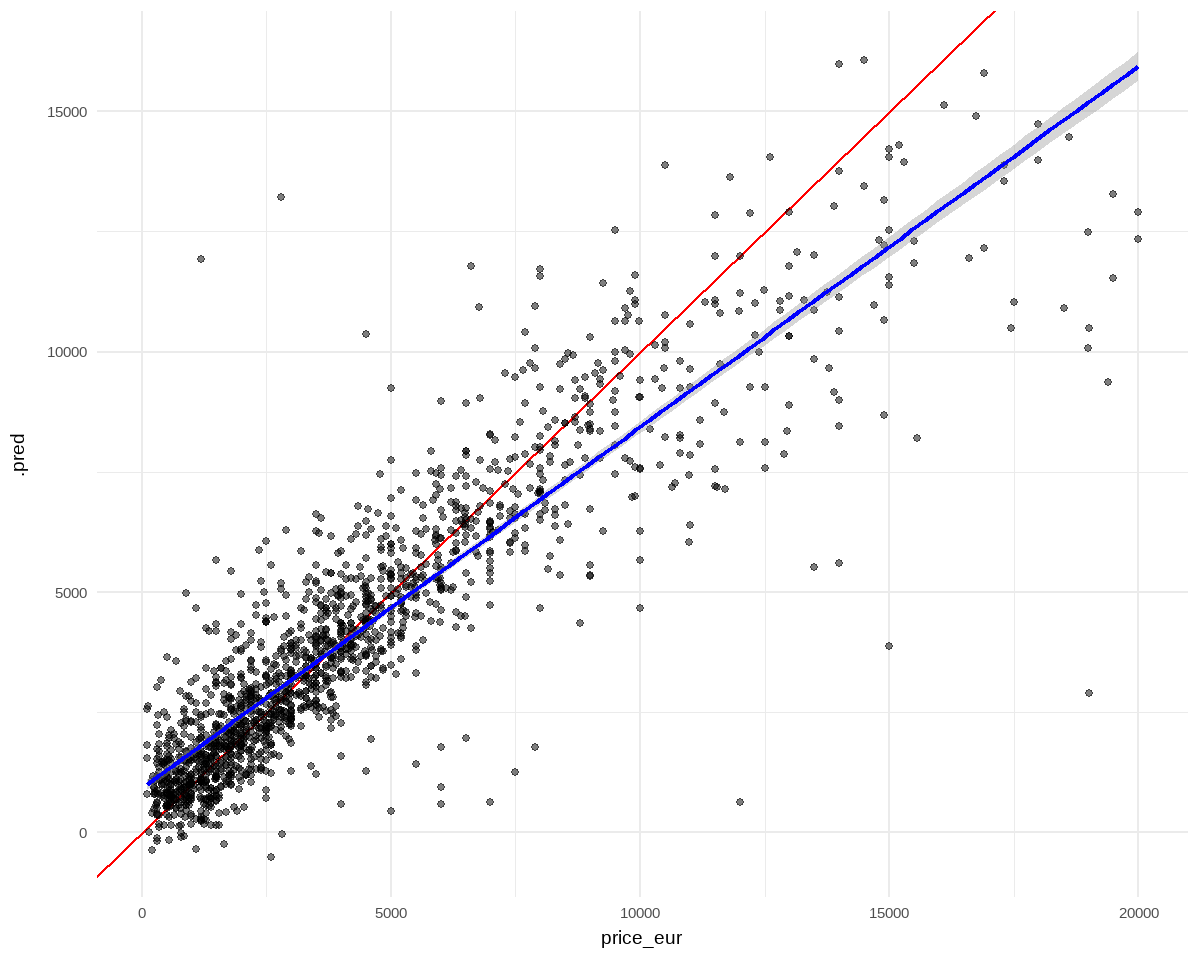

In [126]:
final_predictions_svm %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  theme_minimal(base_size = 14)
  labs(title = "Best SVM model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

#### Worst and best predictions for SVM model

In [127]:
predictions <- final_svm_res %>%
  collect_predictions() %>%
  mutate(error = abs(price_eur - .pred))

best_5 <- predictions %>%
  slice_min(order_by = error, n = 5)

worst_5 <- predictions %>%
  slice_max(order_by = error, n = 5)

cat("Best predictions:\n")
best_5 %>% as.data.frame()
cars[best_5$.row, ]

cat("Worst predictions:\n")
worst_5 %>% as.data.frame()
cars[worst_5$.row, ]

Best predictions:


.pred,id,price_eur,.row,.config,error
<dbl>,<chr>,<int>,<int>,<chr>,<dbl>
698.6608,train/test split,700,5929,pre0_mod0_post0,1.339151
6498.4925,train/test split,6500,4469,pre0_mod0_post0,1.507536
1201.9791,train/test split,1200,6669,pre0_mod0_post0,1.979077
2402.4714,train/test split,2400,5782,pre0_mod0_post0,2.471393
1997.4570,train/test split,2000,4820,pre0_mod0_post0,2.542964


id,views,favorite,brand,model,days_passed,year,ac,emission_class,seats,⋯,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds,price_eur
<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>
6166,1371,18,Renault,Scenic,7,2002,1,2,5,⋯,275000,11957,1900,0,5,diesel,minivan,0,5,700
4678,61,0,Opel,Insignia,7,2012,2,5,5,⋯,225000,17308,1996,0,5,diesel,caravan,0,6,6500
6928,483,6,Toyota,Yaris,7,2000,0,4,5,⋯,280000,11200,980,1,5,petrol + gas,hatchback,0,5,1200
6015,86,2,Renault,Megane,7,2004,2,4,4,⋯,205650,9793,1870,0,3,diesel,cabriolet,0,6,2400
5035,1216,17,Peugeot,206,14,2006,1,4,5,⋯,234834,12360,1560,0,5,diesel,hatchback,0,5,2000


Worst predictions:


.pred,id,price_eur,.row,.config,error
<dbl>,<chr>,<int>,<int>,<chr>,<dbl>
2903.8487,train/test split,19000,5880,pre0_mod0_post0,16096.15
622.6409,train/test split,11999,146,pre0_mod0_post0,11376.36
3884.3229,train/test split,15000,981,pre0_mod0_post0,11115.68
11921.9567,train/test split,1200,3024,pre0_mod0_post0,10721.96
13223.9775,train/test split,2800,6233,pre0_mod0_post0,10423.98


id,views,favorite,brand,model,days_passed,year,ac,emission_class,seats,⋯,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds,price_eur
<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>
6115,14,0,Renault,Scenic,0,2007,2,4,5,⋯,230000,12778,1500,0,5,diesel,limousine,0,6,19000
152,470,0,Audi,80,21,1982,0,1,5,⋯,50000,1163,1982,0,5,petrol,limousine,0,5,11999
1040,119,2,BMW,320,14,2004,0,4,5,⋯,25618,1220,1900,0,5,petrol,limousine,0,5,15000
3151,6681,10,Jaguar,XF,7,2010,2,5,5,⋯,120000,8000,3000,1,5,diesel,limousine,2,0,1200
6474,334,5,Skoda,Octavia,21,2021,0,4,5,⋯,230000,57500,1900,0,5,diesel,caravan,0,5,2800


## Model 4 - KNN

In [128]:
knn_spec <- nearest_neighbor(neighbors = 15) %>%
  set_engine("kknn") %>%
  set_mode("regression")

knn_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(knn_spec)

metrics <- metric_set(rmse, rsq, mae)

knn_res <- last_fit(knn_wf, car_split)

knn_base_pred <- knn_res %>% 
  collect_predictions()

metrics(base_predictions, truth = price_eur, estimate = .pred)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1477.9519329
rsq,standard,0.8399932
mae,standard,913.9682963


`geom_smooth()` using formula = 'y ~ x'


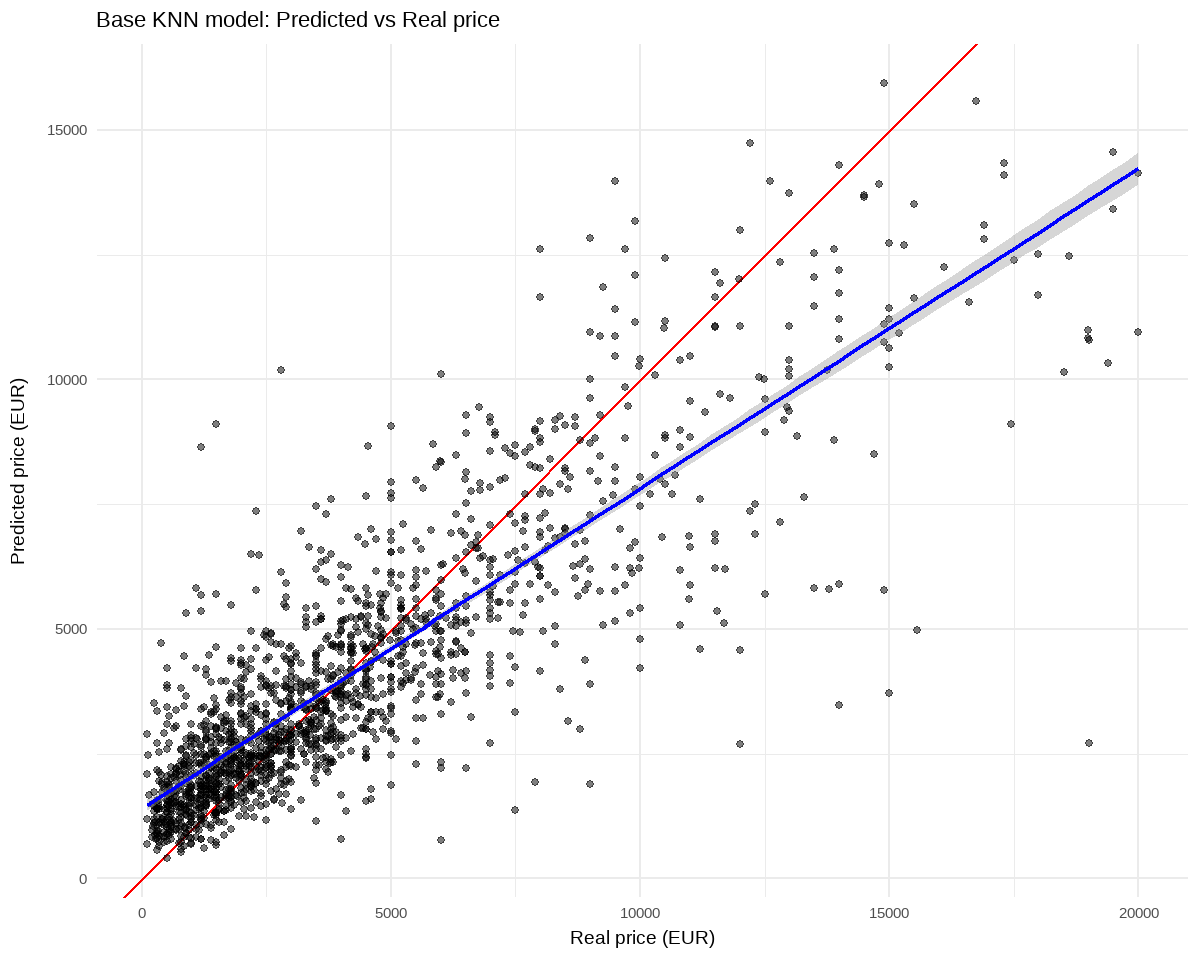

In [129]:
knn_base_pred %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  theme_minimal(base_size = 14) +
  labs(title = "Base KNN model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

In [130]:
cores <- parallel::detectCores(logical = FALSE)
cl <- makePSOCKcluster(cores - 1)
registerDoParallel(cl)

knn_spec <- nearest_neighbor(
    neighbors = tune(),
    weight_func = tune(),
    dist_power = tune()
  ) %>%
  set_engine("kknn") %>%
  set_mode("regression")

knn_wf <- workflow() %>%
  add_recipe(recipe_price) %>%
  add_model(knn_spec)

train_tiny <- train_data %>% slice_sample(prop = 0.3)
car_folds <- vfold_cv(train_tiny, v = 5, strata = price_eur)

In [131]:
knn_tune_res <- tune_grid(
  knn_wf,
  resamples = car_folds,
  grid = 10,
  metrics = metric_set(rmse, rsq, mae),
  control = control_grid(save_pred = TRUE, parallel_over = "everything")
)

knn_tune_res %>% collect_metrics() %>% head(10)

stopCluster(cl)

neighbors,weight_func,dist_power,.metric,.estimator,mean,n,std_err,.config
<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,gaussian,0.9444444,mae,standard,1739.0275798,5,38.06014657,pre0_mod01_post0
1,gaussian,0.9444444,rmse,standard,2623.3982578,5,78.43415839,pre0_mod01_post0
1,gaussian,0.9444444,rsq,standard,0.5502348,5,0.02741298,pre0_mod01_post0
2,triangular,1.1555556,mae,standard,1649.6639209,5,46.19954879,pre0_mod02_post0
2,triangular,1.1555556,rmse,standard,2509.3413251,5,61.14450596,pre0_mod02_post0
2,triangular,1.1555556,rsq,standard,0.5777454,5,0.02221287,pre0_mod02_post0
4,epanechnikov,1.7888889,mae,standard,1642.1384661,5,34.55442915,pre0_mod03_post0
4,epanechnikov,1.7888889,rmse,standard,2454.7396859,5,33.69445887,pre0_mod03_post0
4,epanechnikov,1.7888889,rsq,standard,0.5929225,5,0.01818095,pre0_mod03_post0


In [132]:
best_knn <- knn_tune_res %>% select_best(metric = "mae")

final_knn_wf <- knn_wf %>% finalize_workflow(best_knn)

final_knn_res <- last_fit(final_knn_wf, car_split)

In [133]:
final_predictions_knn <- final_knn_res %>%
  collect_predictions()

best_knn %>% as.data.frame()
metrics(final_predictions_knn, truth = price_eur, estimate = .pred)

neighbors,weight_func,dist_power,.config
<int>,<chr>,<dbl>,<chr>
13,inv,0.3111111,pre0_mod09_post0


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1678.6016397
rsq,standard,0.7949961
mae,standard,1064.1151074


`geom_smooth()` using formula = 'y ~ x'


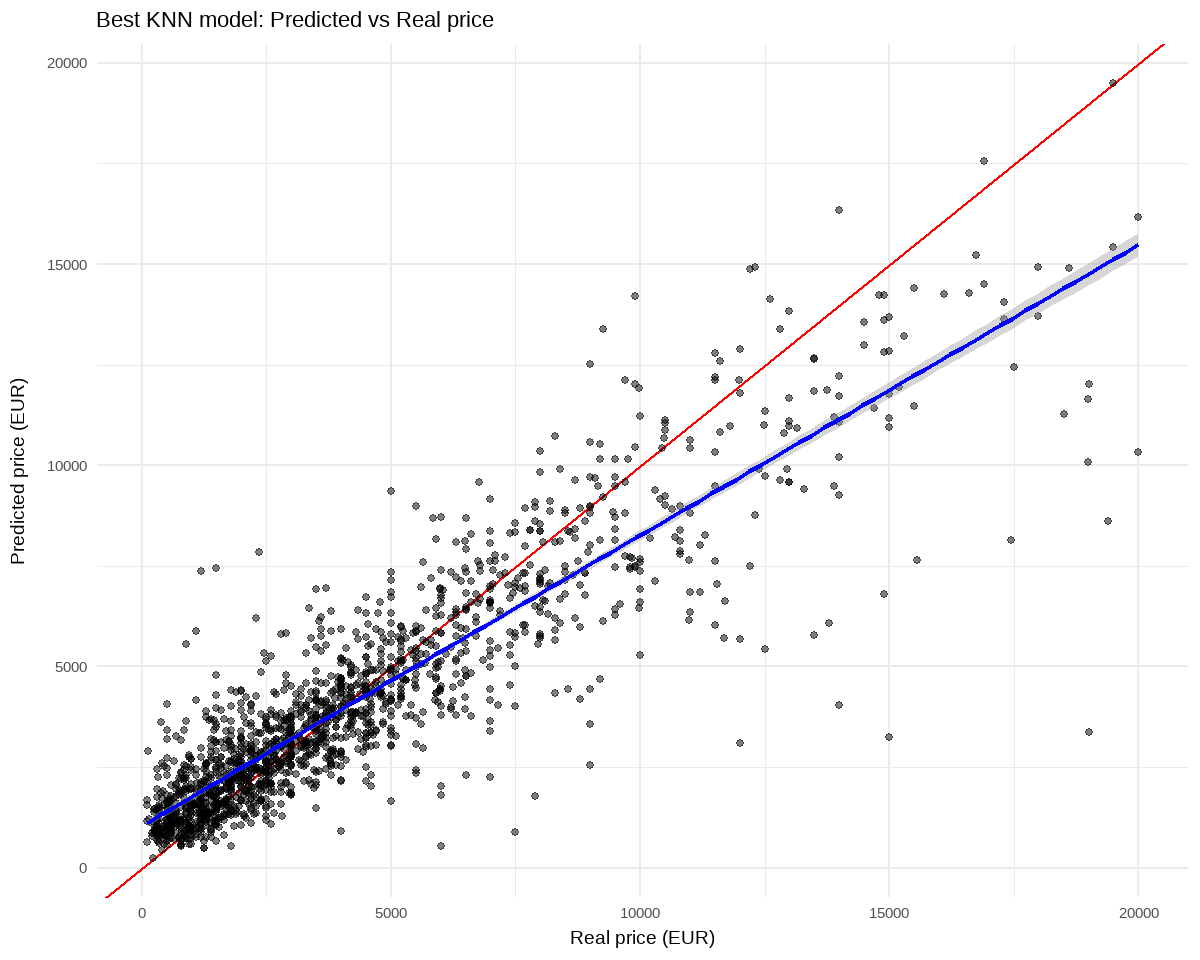

In [134]:
final_predictions_knn %>%
  ggplot(aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  theme_minimal(base_size = 14) +
  labs(title = "Best KNN model: Predicted vs Real price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

In [135]:
predictions <- final_knn_res %>%
  collect_predictions() %>%
  mutate(error = abs(price_eur - .pred))

best_5 <- predictions %>%
  slice_min(order_by = error, n = 5)

worst_5 <- predictions %>%
  slice_max(order_by = error, n = 5)

cat("Best predictions:\n")
best_5 %>% as.data.frame()
cars[best_5$.row, ]

cat("Worst predictions:\n")
worst_5 %>% as.data.frame()
cars[worst_5$.row, ]

Best predictions:


.pred,id,price_eur,.row,.config,error
<dbl>,<chr>,<int>,<int>,<chr>,<dbl>
5399.998,train/test split,5400,1361,pre0_mod0_post0,0.002239570
230.004,train/test split,230,8032,pre0_mod0_post0,0.003975656
1700.008,train/test split,1700,5124,pre0_mod0_post0,0.008300428
1350.012,train/test split,1350,1713,pre0_mod0_post0,0.011775235
5649.971,train/test split,5650,1864,pre0_mod0_post0,0.028934770


id,views,favorite,brand,model,days_passed,year,ac,emission_class,seats,⋯,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds,price_eur
<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>
1448,55,0,Citroen,C3,7,2014,1,5,5,⋯,126000,11455,1200,0,5,petrol,hatchback,0,5,5400
8338,225,8,Zastava,Koral In,7,2008,0,3,5,⋯,100000,5882,1100,0,3,petrol + gas,limousine,0,5,230
5341,144,1,Peugeot,307,7,2003,2,4,5,⋯,350000,15909,1998,0,5,petrol + gas,limousine,0,5,1700
1807,10,0,Citroen,Xsara Picasso,1,2001,1,4,5,⋯,400000,16667,1800,0,5,petrol + gas,minivan,0,5,1350
1964,24,0,Fiat,500L,2,2015,0,4,5,⋯,200500,20050,1300,0,5,diesel,hatchback,0,5,5650


Worst predictions:


.pred,id,price_eur,.row,.config,error
<dbl>,<chr>,<int>,<int>,<chr>,<dbl>
3370.683,train/test split,19000,5880,pre0_mod0_post0,15629.317
3241.625,train/test split,15000,981,pre0_mod0_post0,11758.375
8622.167,train/test split,19400,5017,pre0_mod0_post0,10777.833
4049.474,train/test split,14000,3306,pre0_mod0_post0,9950.526
10333.214,train/test split,19999,563,pre0_mod0_post0,9665.786


id,views,favorite,brand,model,days_passed,year,ac,emission_class,seats,⋯,mileage_km,kms_per_year,engine_capacity_cc,type_of_drive,doors,fuel,car_type,gearbox,speeds,price_eur
<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>
6115,14,0,Renault,Scenic,0,2007,2,4,5,⋯,230000,12778,1500,0,5,diesel,limousine,0,6,19000
1040,119,2,BMW,320,14,2004,0,4,5,⋯,25618,1220,1900,0,5,petrol,limousine,0,5,15000
5232,92,1,Peugeot,3008,21,2018,1,4,5,⋯,69900,9986,1997,0,5,diesel,suv,0,6,19400
3455,27,0,Mazda,6,1,2013,2,4,5,⋯,80000,6667,2000,0,5,petrol,limousine,0,6,14000
588,103,0,Audi,A6,21,2016,2,6,5,⋯,208000,23111,1968,0,5,diesel,limousine,0,6,19999


## Comparing the models

In [136]:
prediction_list <- list(
  RandomForest = final_predictions_rf,
  XGBoost = final_predictions_xgb,
  SVM = final_predictions_svm,
  kNN = final_predictions_knn
)

comparison_table <- prediction_list %>%
  map_df(~ metrics(.x, truth = price_eur, estimate = .pred), .id = "model") %>%
  select(model, .metric, .estimate) %>%
  pivot_wider(names_from = .metric, values_from = .estimate) %>%
  arrange(mae)

print(comparison_table)

# A tibble: 4 × 4
  model         rmse   rsq   mae
  <chr>        <dbl> <dbl> <dbl>
1 XGBoost      1439. 0.844  869.
2 RandomForest 1464. 0.839  884.
3 SVM          1654. 0.797 1006.
4 kNN          1679. 0.795 1064.


`geom_smooth()` using formula = 'y ~ x'


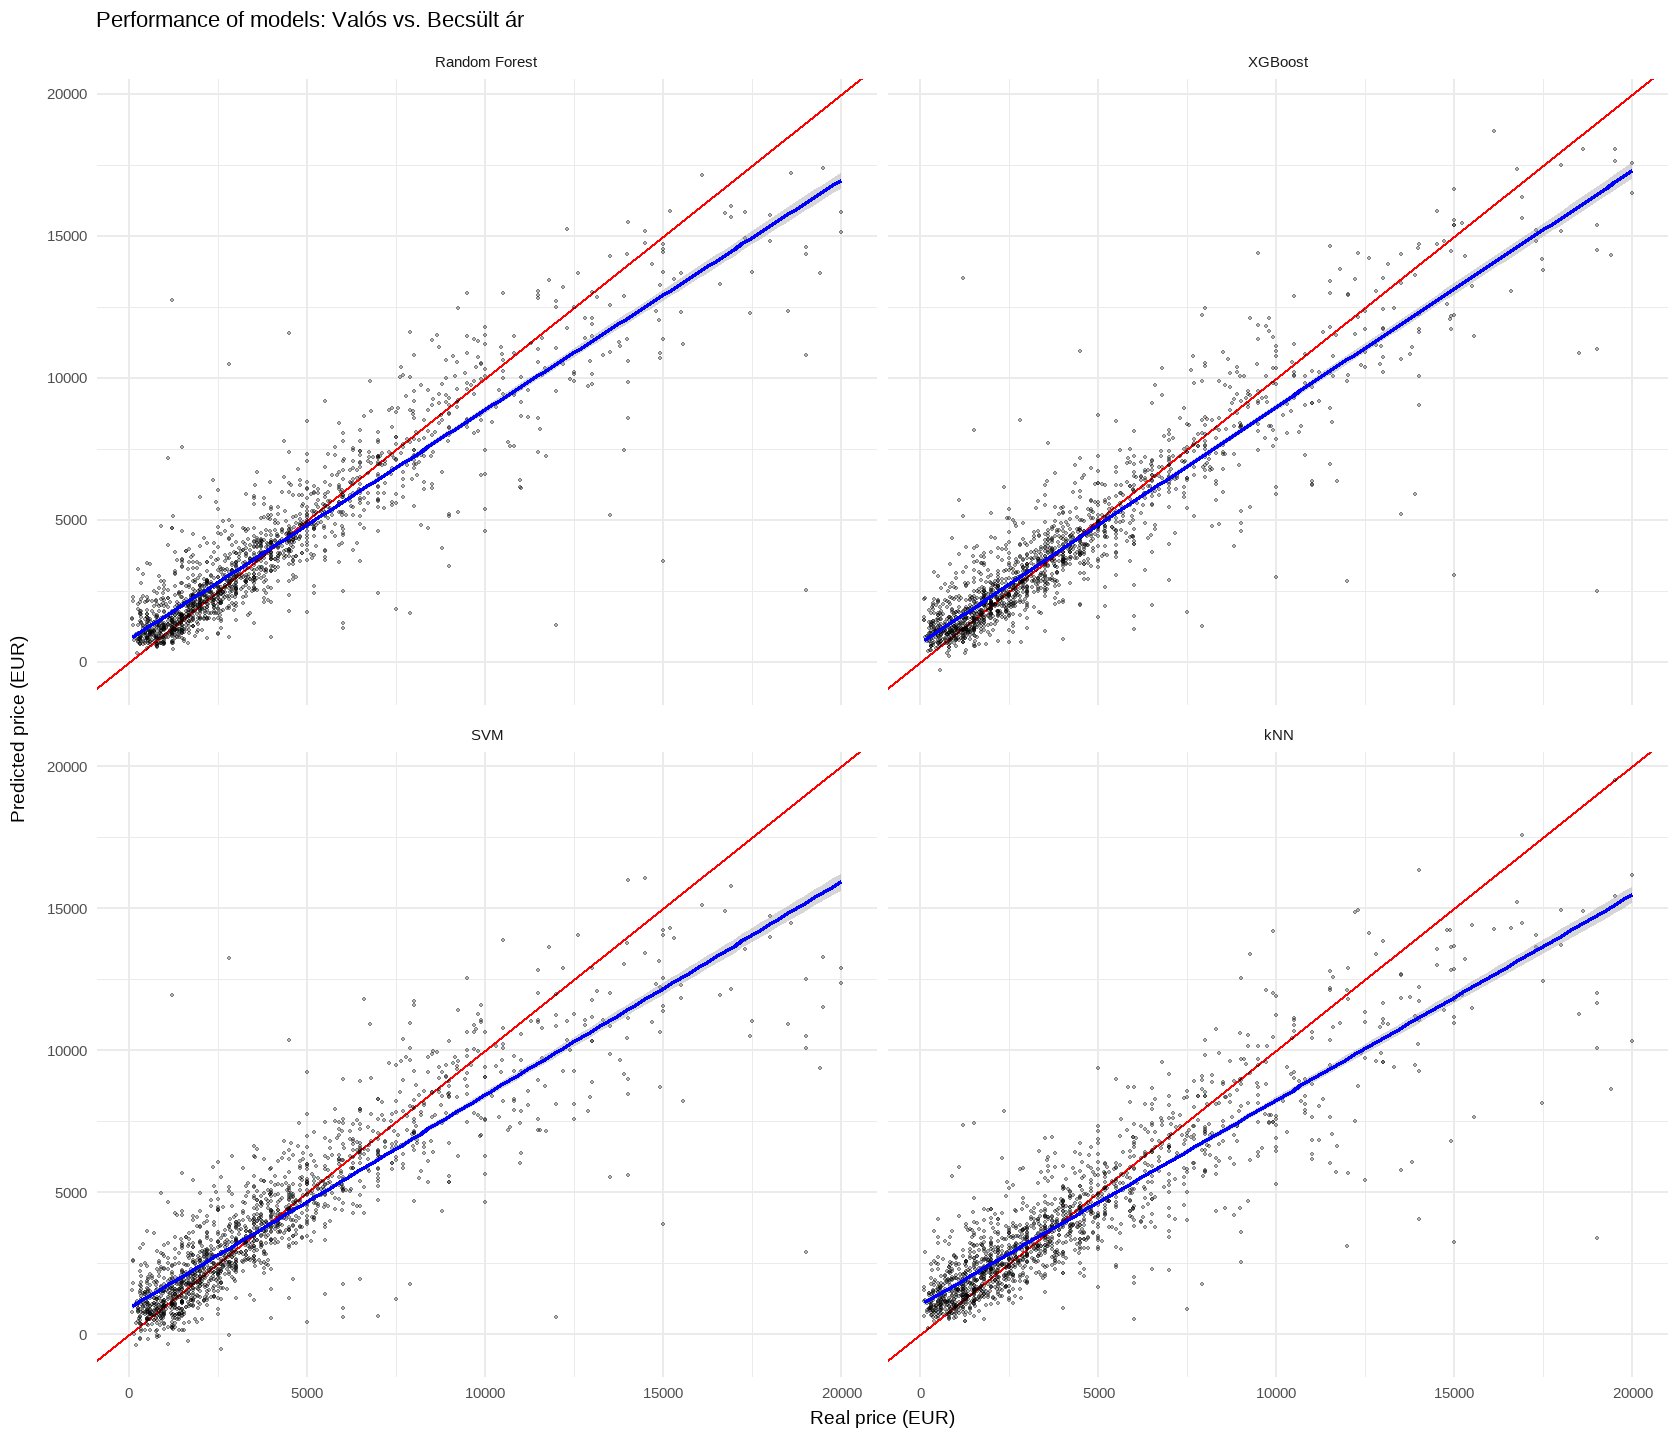

In [142]:
options(repr.plot.width = 14, repr.plot.height = 12)

all_preds <- bind_rows(
  final_predictions_rf  %>% mutate(model = "Random Forest"),
  final_predictions_xgb %>% mutate(model = "XGBoost"),
  final_predictions_svm %>% mutate(model = "SVM"),
  final_predictions_knn %>% mutate(model = "kNN")
) %>%
  mutate(model = factor(model, levels = c("Random Forest", "XGBoost", "SVM", "kNN")))

ggplot(all_preds, aes(x = price_eur, y = .pred)) +
  geom_abline(color = "red") +
  geom_point(alpha = 0.3, size = 0.8) +
  geom_smooth(method = "lm", color = "blue", se = TRUE) +
  facet_wrap(~model) +
  theme_minimal(base_size = 14) +
  labs(title = "Performance of models: Real vs. Predicted price",
       x = "Real price (EUR)", y = "Predicted price (EUR)")

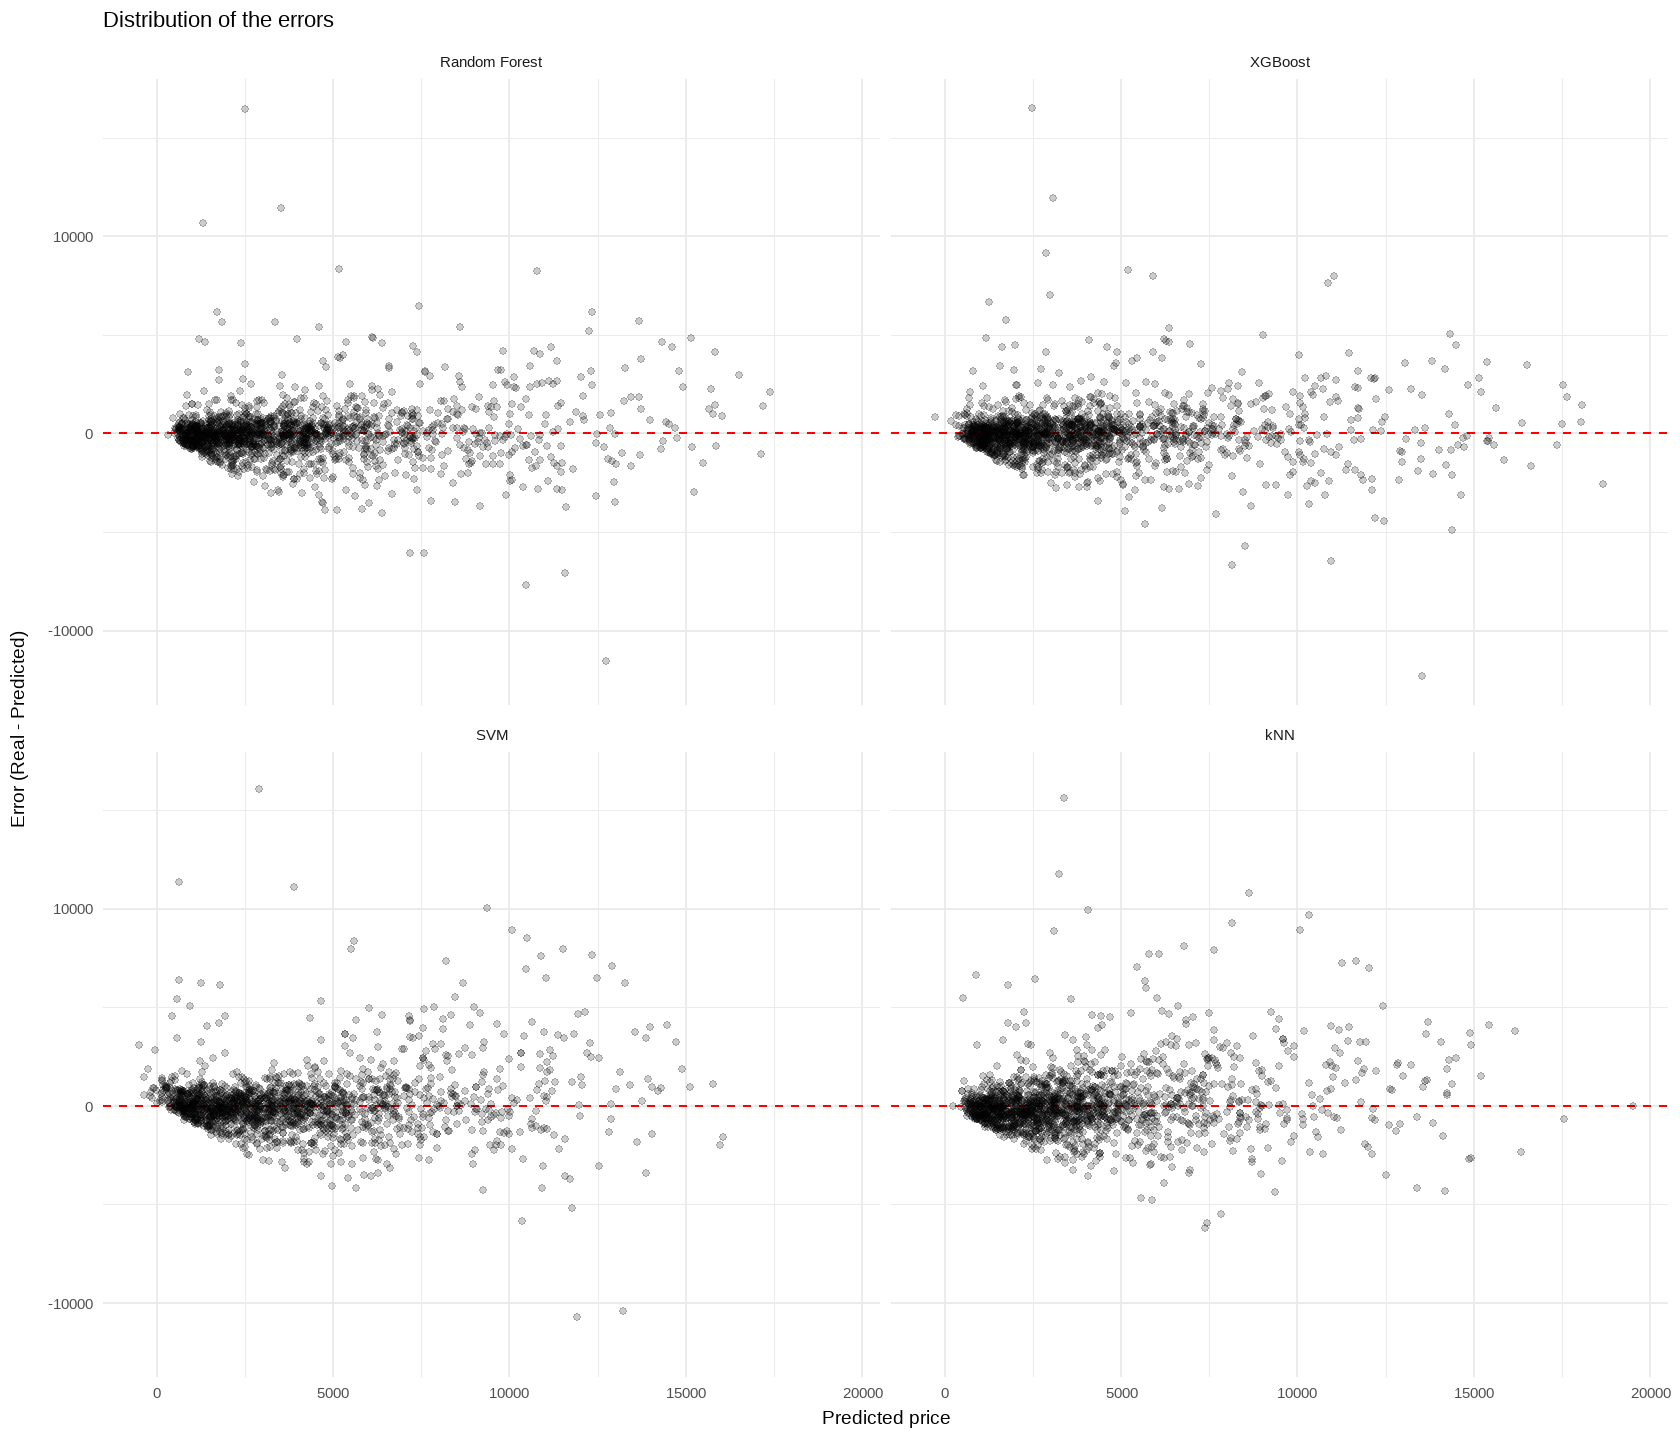

In [144]:
all_preds %>%
  mutate(residual = price_eur - .pred) %>%
  ggplot(aes(x = .pred, y = residual)) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  geom_point(alpha = 0.2) +
  facet_wrap(~model) +
  theme_minimal(base_size = 14) +
  labs(title = "Distribution of the errors",
       x = "Predicted price", y = "Error (Real - Predicted)")

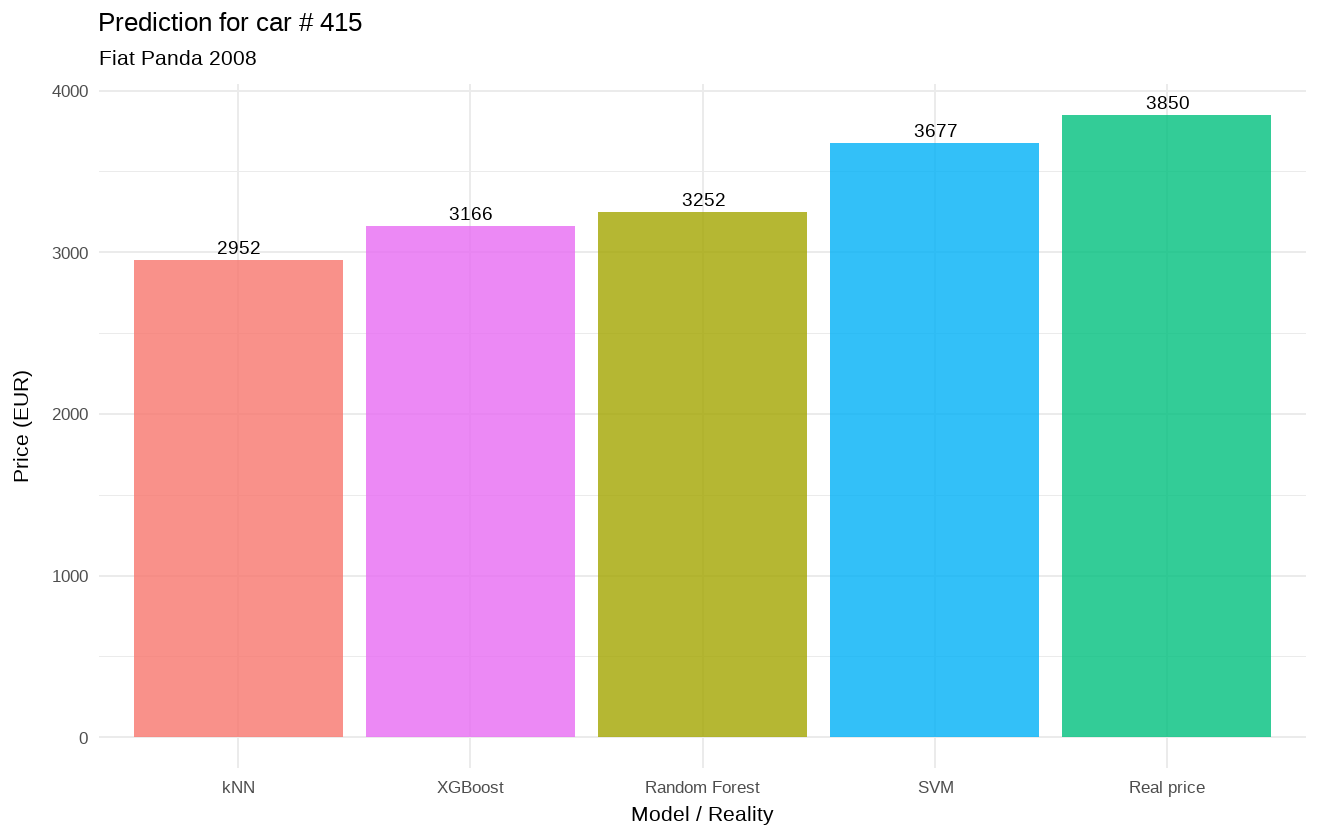

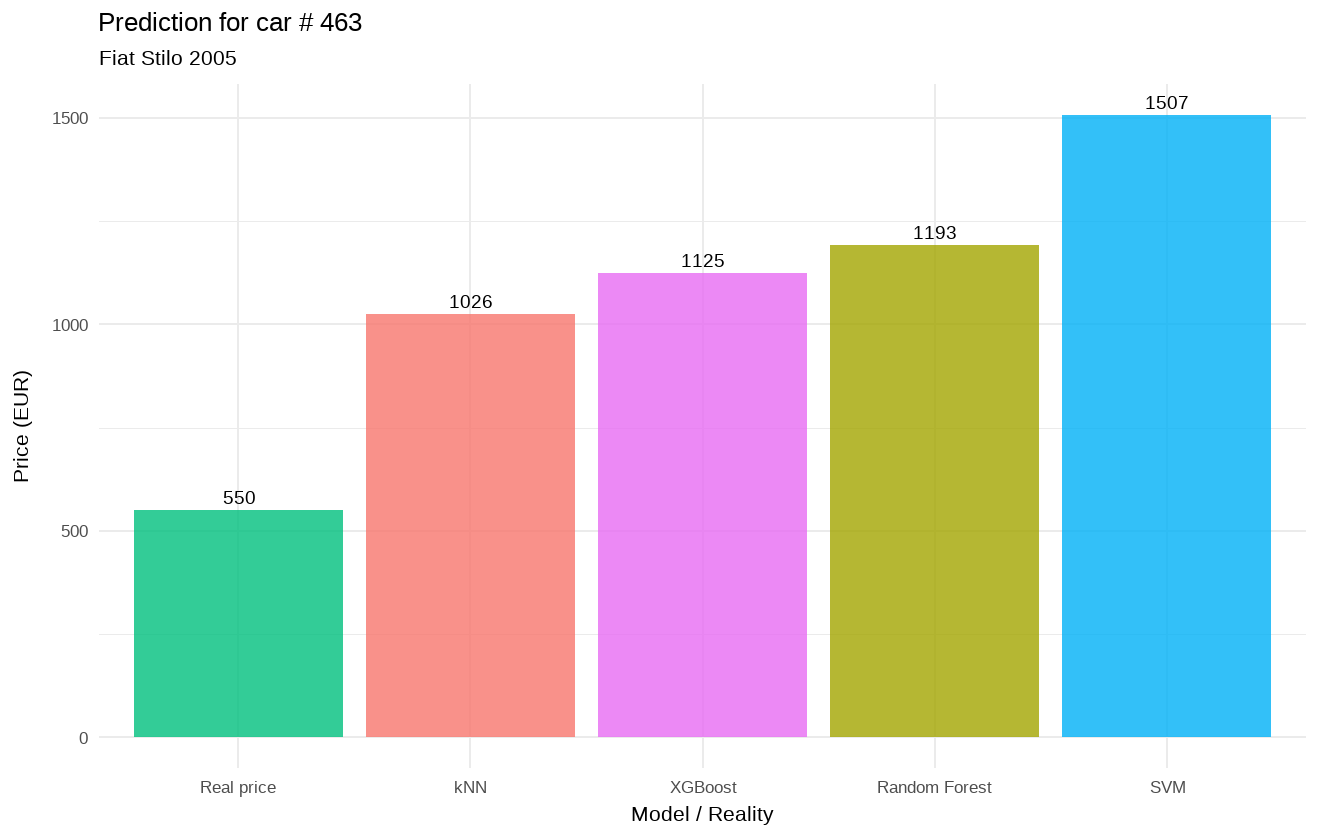

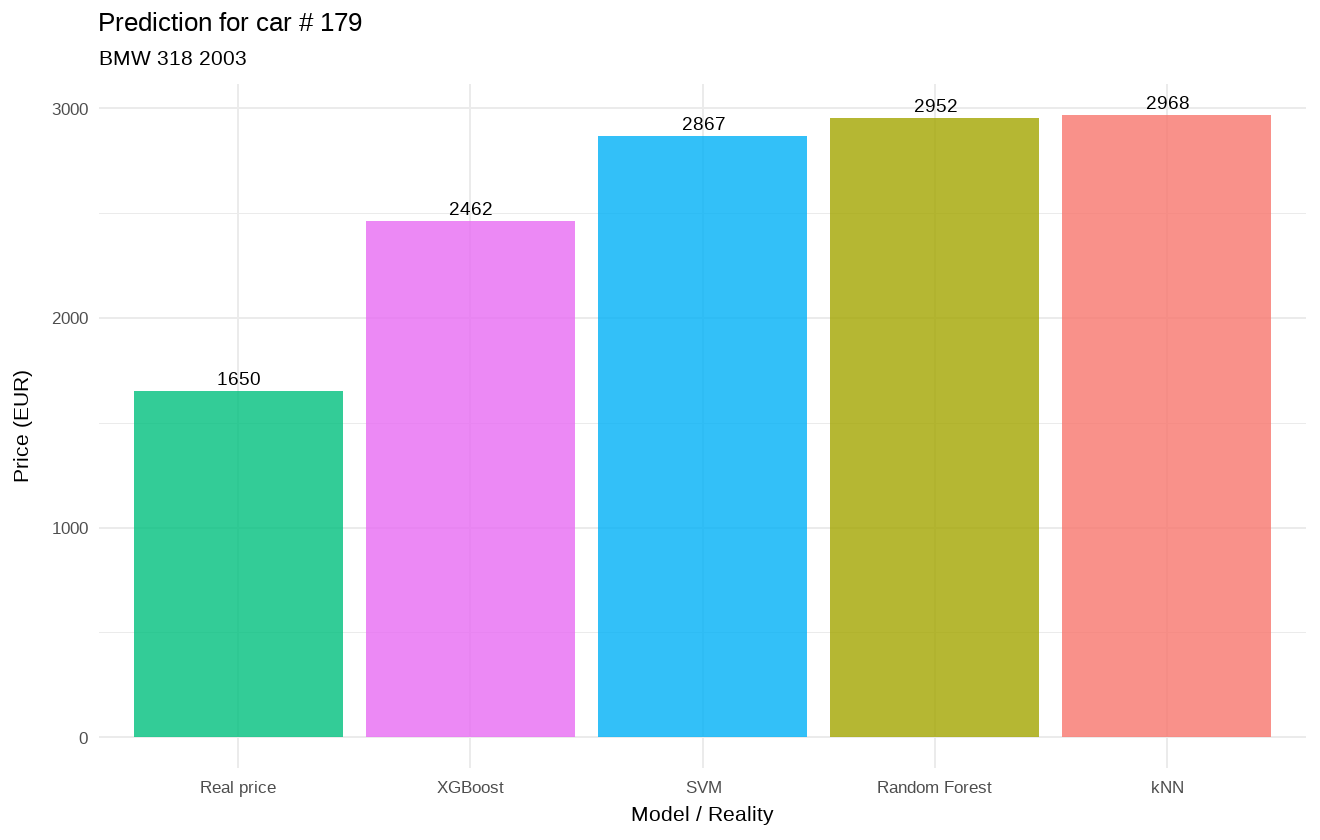

In [162]:
options(repr.plot.width = 11, repr.plot.height = 7)

set.seed(123)

car_test <- testing(car_split)
random_indices <- sample(1:nrow(car_test), 3)

walk(random_indices, function(idx) {
  random_car <- car_test %>% slice(idx)
  
  comparison <- data.frame(
    Type = c("Real price", "Random Forest", "XGBoost", "SVM", "kNN"),
    Price_EUR = c(
      car_test$price_eur[idx],
      final_predictions_rf$.pred[idx],
      final_predictions_xgb$.pred[idx],
      final_predictions_svm$.pred[idx],
      final_predictions_knn$.pred[idx]
    )
  )
  
  p <- ggplot(comparison, aes(x = reorder(Type, Price_EUR), y = Price_EUR, fill = Type)) +
    geom_col(alpha = 0.8) +
    geom_text(aes(label = round(Price_EUR, 0)), vjust = -0.5, size = 5) +
    theme_minimal(base_size = 16) +
    labs(title = paste("Prediction for car #", idx),
         subtitle = paste(random_car$brand, random_car$model, random_car$year),
         x = "Models / Reality", y = "Price (EUR)") +
    theme(legend.position = "none")
  
  print(p)
})


In [145]:
# SVM fontosság (permutációs módszerrel)
svm_vimp <- final_svm_res %>%
  extract_fit_parsnip() %>%
  vi(method = "permute", 
     target = "price_eur", 
     metric = "mae",
     pred_wrapper = final_predictions_svm,
     train = training(car_split))

# kNN fontosság (permutációs módszerrel)
knn_vimp <- final_knn_res %>%
  extract_fit_parsnip() %>%
  vi(method = "permute", 
     target = "price_eur", 
     metric = "mae",
     pred_wrapper = predict,
     train = training(car_split))


ERROR: Error in pred_wrapper(object, newdata = train_x): could not find function "pred_wrapper"


In [164]:
p1 <- vip(base_res %>% extract_fit_parsnip()) + labs(title = "Random Forest")
p2 <- vip(final_xgb_res %>% extract_fit_parsnip()) + labs(title = "XGBoost")
p3 <- vip(svm_vimp) + labs(title = "SVM (Permutation)")
p4 <- vip(knn_vimp) + labs(title = "kNN (Permutation)")

(p1 + p2) / (p3 + p4)

ERROR: Error: object 'svm_vimp' not found
